# Phase 2 Submission: Empirical Investigation of High Court Bail Cases

**Project question:** How do bail type and High Court context shape delay, pendency, and observed outcomes in Indian High Court bail cases?

**Submitted by:**
- Tushar Singh (22322032)
- Pranav Pipariya (22322022)
- Tanishq Gupta (22322031)
- Kavish Jain (22322017)
- Yash Kumar (22322034)

This Phase 2 notebook builds on the Phase 1 I/O and EDA submission. It moves from broad exploration to five applied empirical investigations, one for each team member, using the DAKSH High Court Bail Case dataset.

**Important interpretation note:** this notebook does **not** provide legal advice or individual bail predictions. Its prediction component estimates historical long-delay risk from case metadata in this dataset. It should be interpreted as decision-support context for research, not as a forecast of any person's legal outcome.

**Data context:** DAKSH describes bail data analysis as important for understanding undertrial detention, timely hearings, and process reform. DAKSH also warns that data availability gaps and other limitations can affect findings. We therefore report coverage, missingness, and cohort restrictions before interpreting results.

Sources used for framing and citation:
- DAKSH High Court Data Portal: https://www.dakshindia.org/daksh-high-court-data-portal/
- DAKSH High Court Bail Dashboard: https://database.dakshindia.org/bail-dashboard/
- Local codebook: `docs/Codebook_DAKSH_HighCourt_2023.pdf`

## Abstract

This study examines nearly **0.93 million High Court bail case records** to understand how bail type and court context relate to case processing. The analysis focuses on three connected outcomes: disposal delay, pending burden, and observed disposal outcomes where outcome labels are available.

The analysis produces five main conclusions:

1. **Bail cases are structurally heterogeneous.** Regular bail accounts for most records, anticipatory bail is also substantial, and cancellation is rare but much slower.
2. **Disposal time differs sharply by bail type.** In the disposed cohort, regular bail has a median disposal time of about 23 days, anticipatory bail about 37 days, and cancellation about 268 days.
3. **Court context matters even after adjustment.** Raw medians are not enough because courts differ in bail-type and case-type composition, so the notebook builds an adjusted court-delay index.
4. **Filing-stage metadata contains useful delay-risk signal.** The model estimates long-delay risk from case metadata available near filing, while excluding post-outcome variables.
5. **Outcome labels are informative but incomplete.** Observed bail outcomes are analyzed only in the labeled disposed subset, with coverage shown before interpretation.

The project is organized around transparent measurement, careful cohort definition, and restrained interpretation. Each empirical claim is linked to a table or figure and paired with the relevant data limitation.

Each investigation follows the same reading pattern: it states the empirical question, defines the analytical cohort, generates tables and figures, and then explains what the result can and cannot support. This makes the notebook easier to read as both a technical workflow and an empirical report.

## Research Design And Evidence Structure

The starting point is that bail is not one uniform category. Regular bail, anticipatory bail, and cancellation cases enter High Courts through different procedural paths and registry conventions. The central empirical task is therefore to separate **administrative patterns in bail processing** from patterns that may reflect court-specific data entry, missing legal metadata, or incomplete disposal labels.

The evidence is built in five layers:

1. **Measurement quality first.** We validate record counts, parse mixed date formats, quantify missingness, and define which fields can safely support full-cohort analysis.
2. **Bail-type composition.** We map how bail categories differ across courts, years, and case-type conventions.
3. **Delay and court inequality.** We compare raw disposal times, then add an adjusted delay index so court comparisons are not driven only by bail-type or filing-year composition.
4. **Prediction as decision-support context.** We estimate long-delay risk using only filing-stage metadata, with explicit leakage controls and baseline comparisons.
5. **Outcome labels with restraint.** We analyze observed outcomes only where labels are available, and we keep those claims separate from the stronger delay and pendency findings.

This structure keeps the strongest claims tied to the most reliable fields. Weaker fields are still used when they add value, but only with coverage checks and explicit limits on interpretation.

## Methodological Principles

The notebook follows six methodological principles:

- **Reproducibility:** all files are loaded relative to the project folder.
- **Date validity:** mixed date formats are parsed explicitly and validated.
- **Outcome restraint:** disposal outcomes are analyzed only where labels exist.
- **Prediction integrity:** the long-delay model excludes variables that reveal post-filing outcomes.
- **Careful court comparison:** court rankings are treated as descriptive benchmarks, not causal claims about judicial quality.
- **Model transparency:** the predictive model is implemented with NumPy and explained through coefficients, calibration, baselines, and robustness checks.

## 0. Setup And Reproducibility

The notebook is designed to run from the project folder without absolute paths. It creates all tables and figures under `outputs/`.

In [1]:
import json
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", palette="Set2", context="notebook")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 180

PROJECT_DIR = Path(".").resolve()
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
for path in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

candidate_paths = [
    PROJECT_DIR / "Compiled Bail case data.csv",
    PROJECT_DIR / "data" / "Compiled Bail case data.csv",
    PROJECT_DIR.parent / "Compiled Bail case data.csv",
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not locate Compiled Bail case data.csv.")

try:
    data_path_display = DATA_PATH.relative_to(PROJECT_DIR)
except ValueError:
    data_path_display = DATA_PATH.name

print("Project folder: .")
print(f"Data path: {data_path_display}")
print(f"Dataset size: {DATA_PATH.stat().st_size / (1024**2):,.2f} MB")
print(f"Random seed: {RANDOM_SEED}")

Project folder: .
Data path: Compiled Bail case data.csv
Dataset size: 318.62 MB
Random seed: 42


## Project Workflow Diagram

The workflow below shows how the raw DAKSH bail case data is converted into validated analytical cohorts, empirical investigations, generated outputs, and final interpretation. It is included to make the project structure transparent and reproducible.

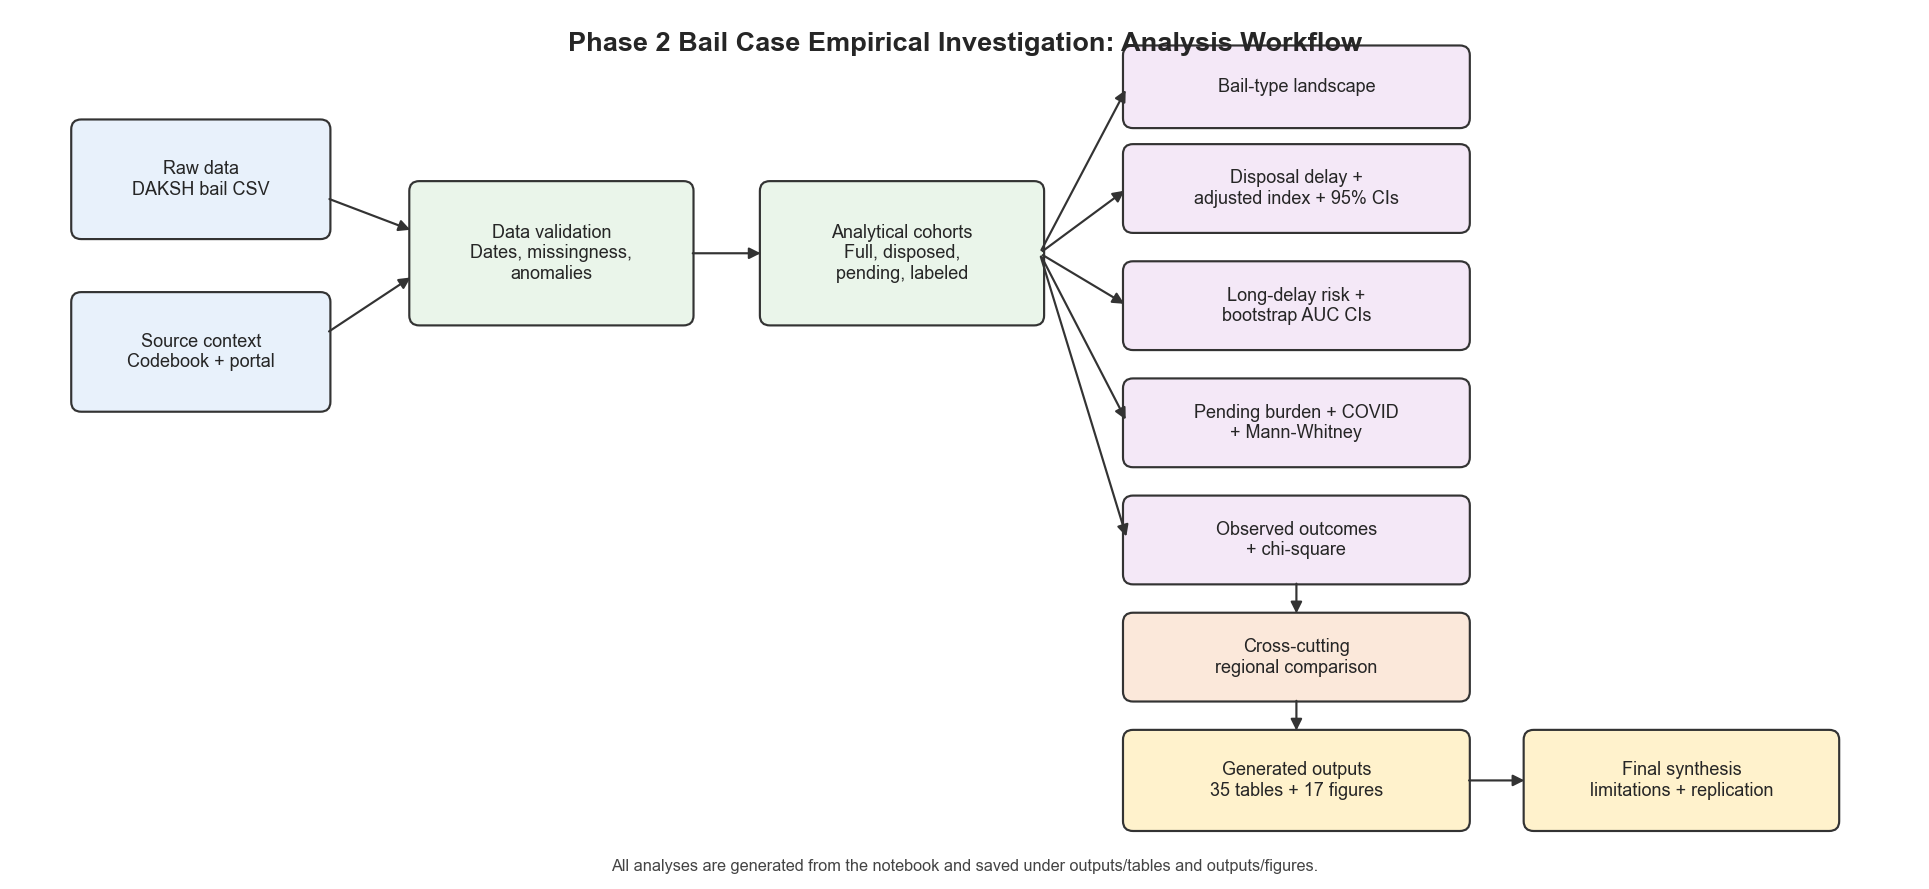

Saved figure: outputs/figures/00_project_workflow.png


In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def draw_workflow_diagram():
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.set_xlim(0, 15.2)
    ax.set_ylim(0, 7)
    ax.axis("off")

    nodes = {
        "raw": (0.5, 5.2, 2.0, 0.9, "Raw data\nDAKSH bail CSV"),
        "codebook": (0.5, 3.8, 2.0, 0.9, "Source context\nCodebook + portal"),
        "clean": (3.2, 4.5, 2.2, 1.1, "Data validation\nDates, missingness,\nanomalies"),
        "cohorts": (6.0, 4.5, 2.2, 1.1, "Analytical cohorts\nFull, disposed,\npending, labeled"),
        "inv1": (8.9, 6.10, 2.7, 0.60, "Bail-type landscape"),
        "inv2": (8.9, 5.25, 2.7, 0.65, "Disposal delay +\nadjusted index + 95% CIs"),
        "inv3": (8.9, 4.30, 2.7, 0.65, "Long-delay risk +\nbootstrap AUC CIs"),
        "inv4": (8.9, 3.35, 2.7, 0.65, "Pending burden + COVID\n+ Mann-Whitney"),
        "inv5": (8.9, 2.40, 2.7, 0.65, "Observed outcomes\n+ chi-square"),
        "regional": (8.9, 1.45, 2.7, 0.65, "Cross-cutting\nregional comparison"),
        "outputs": (8.9, 0.40, 2.7, 0.75, "Generated outputs\n35 tables + 17 figures"),
        "interpret": (12.1, 0.40, 2.45, 0.75, "Final synthesis\nlimitations + replication"),
    }

    colors = {
        "raw": "#E8F1FB",
        "codebook": "#E8F1FB",
        "clean": "#EAF5EA",
        "cohorts": "#EAF5EA",
        "regional": "#FBE8DA",
        "outputs": "#FFF2CC",
        "interpret": "#FFF2CC",
    }

    for key, (x, y, w, h, label) in nodes.items():
        color = colors.get(key, "#F4E8F7")
        patch = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.035,rounding_size=0.08",
            linewidth=1.2,
            edgecolor="#333333",
            facecolor=color,
        )
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=10, linespacing=1.18)

    def connect(a, b, y_offset_a=0.0, y_offset_b=0.0):
        ax1, ay1, aw, ah, _ = nodes[a]
        bx, by, bw, bh, _ = nodes[b]
        start = (ax1 + aw, ay1 + ah / 2 + y_offset_a)
        end = (bx, by + bh / 2 + y_offset_b)
        arrow = FancyArrowPatch(
            start, end,
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.2,
            color="#333333",
            connectionstyle="arc3,rad=0.0",
        )
        ax.add_patch(arrow)

    def connect_points(start, end):
        arrow = FancyArrowPatch(
            start, end,
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.2,
            color="#333333",
            connectionstyle="arc3,rad=0.0",
        )
        ax.add_patch(arrow)

    connect("raw", "clean", y_offset_a=-0.15, y_offset_b=0.18)
    connect("codebook", "clean", y_offset_a=0.15, y_offset_b=-0.18)
    connect("clean", "cohorts")
    for target in ["inv1", "inv2", "inv3", "inv4", "inv5"]:
        connect("cohorts", target)
    inv5_x, inv5_y, inv5_w, _, _ = nodes["inv5"]
    reg_x, reg_y, reg_w, reg_h, _ = nodes["regional"]
    connect_points((inv5_x + inv5_w / 2, inv5_y), (reg_x + reg_w / 2, reg_y + reg_h))
    out_x, out_y, out_w, out_h, _ = nodes["outputs"]
    connect_points((reg_x + reg_w / 2, reg_y), (out_x + out_w / 2, out_y + out_h))
    connect("outputs", "interpret")

    ax.text(
        7.6, 6.75,
        "Phase 2 Bail Case Empirical Investigation: Analysis Workflow",
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
    )
    ax.text(
        7.6, 0.08,
        "All analyses are generated from the notebook and saved under outputs/tables and outputs/figures.",
        ha="center",
        va="center",
        fontsize=9,
        color="#444444",
    )
    plt.tight_layout()
    return fig


fig = draw_workflow_diagram()
workflow_path = FIG_DIR / "00_project_workflow.png"
fig.savefig(workflow_path, bbox_inches="tight", dpi=180)
plt.show()
print(f"Saved figure: {workflow_path.relative_to(PROJECT_DIR)}")

## 1. Load Data And Validate Core Fields

We load analysis-relevant columns, preserve raw string fields, and convert dates/numerics deliberately. A key Phase 2 improvement over naive loading is robust parsing for the two date formats found in the dataset: `YYYY-MM-DD` and `DD-MM-YYYY`.

In [3]:
raw_columns = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
print(f"Raw column count: {len(raw_columns)}")
print(raw_columns)

analysis_cols = [
    "CNR_NUMBER", "CASE_NUMBER", "CASE_TYPE", "CASETYPE_FULLFORM",
    "COMBINED_CASE_NUMBER", "COURT_NAME", "COURT_NUMBER", "NAME_OF_HIGH_COURT",
    "CURRENT_STAGE", "CURRENT_STATUS", "DATE_FILED", "DECISION_DATE",
    "FILING_NUMBER", "HEARING_COUNT", "LAST_SYNC_TIME", "NATURE_OF_DISPOSAL",
    "NATURE_OF_DISPOSAL_OUTCOME", "NATURE_OF_DISPOSAL_BINARY", "NJDG_JUDGE_NAME",
    "PENDING_DAYS", "POLICE_STATION", "REGISTRATION_DATE", "REGISTRATION_NUMBER",
    "RESPONDENT", "UNDER_ACTS", "UNDER_SECTIONS", "YEAR", "DISPOSAL_YEAR",
    "DISPOSAL_DAYS...1", "Mapped_Bail",
]

df = pd.read_csv(
    DATA_PATH,
    usecols=[c for c in analysis_cols if c in raw_columns],
    dtype="string",
    low_memory=False,
)

print(f"Loaded shape: {df.shape}")
display(df.head(3))

Raw column count: 32
['CNR_NUMBER', 'CASE_NUMBER', 'CASE_TYPE', 'CASETYPE_FULLFORM', 'CIVIL_CRIMINAL', 'SUB_CLASSIFICATION', 'COMBINED_CASE_NUMBER', 'COURT_NAME', 'COURT_NUMBER', 'NAME_OF_HIGH_COURT', 'CURRENT_STAGE', 'CURRENT_STATUS', 'DATE_FILED', 'DECISION_DATE', 'FILING_NUMBER', 'HEARING_COUNT', 'LAST_SYNC_TIME', 'NATURE_OF_DISPOSAL', 'NATURE_OF_DISPOSAL_OUTCOME', 'NJDG_JUDGE_NAME', 'PENDING_DAYS', 'POLICE_STATION', 'REGISTRATION_DATE', 'REGISTRATION_NUMBER', 'RESPONDENT', 'UNDER_ACTS', 'UNDER_SECTIONS', 'YEAR', 'NATURE_OF_DISPOSAL_BINARY', 'DISPOSAL_YEAR', 'DISPOSAL_DAYS...1', 'Mapped_Bail']


Loaded shape: (927896, 30)


,CNR_NUMBER,CASE_NUMBER,CASE_TYPE,CASETYPE_FULLFORM,COMBINED_CASE_NUMBER,COURT_NAME,COURT_NUMBER,NAME_OF_HIGH_COURT,CURRENT_STAGE,CURRENT_STATUS,DATE_FILED,DECISION_DATE,FILING_NUMBER,HEARING_COUNT,LAST_SYNC_TIME,NATURE_OF_DISPOSAL,NATURE_OF_DISPOSAL_OUTCOME,NJDG_JUDGE_NAME,PENDING_DAYS,POLICE_STATION,REGISTRATION_DATE,REGISTRATION_NUMBER,RESPONDENT,UNDER_ACTS,UNDER_SECTIONS,YEAR,NATURE_OF_DISPOSAL_BINARY,DISPOSAL_YEAR,DISPOSAL_DAYS...1,Mapped_Bail
0,UPHC010933632010,28389,BAILC,CRIMINAL MISC BAIL CANCELLATION APPLICATION,BAILC-28389-2010,Allahabad Bench,4264,ALLAHABAD HIGH COURT,For Order,Disposed,2010-10-04,2014-07-14,28389,3,2021-02-26,<NA>,<NA>,Justice,<NA>,LISARIGATE,2010-10-04,28389,STATE OF U. P.AND OTHERS,<NA>,<NA>,2010,<NA>,2014,1380,CANCELLATION
1,UPHC010929242010,28169,BAILC,CRIMINAL MISC BAIL CANCELLATION APPLICATION,BAILC-28169-2010,Allahabad Bench,1936,ALLAHABAD HIGH COURT,For Order,Disposed,2010-10-03,2016-09-28,28169,4,2021-02-26,<NA>,<NA>,Justice,<NA>,OBRA,2010-10-03,28169,STATE OF U. P.AND ANOTHER,<NA>,<NA>,2010,<NA>,2016,2188,CANCELLATION
2,UPHC011942192010,28168,BAILC,CRIMINAL MISC BAIL CANCELLATION APPLICATION,BAILC-28168-2010,Allahabad Bench,2153,ALLAHABAD HIGH COURT,For Order,Disposed,2010-10-03,2017-07-27,28168,5,2021-02-26,<NA>,<NA>,Justice,<NA>,OBRA,2010-10-03,28168,STATE OF U. P.AND ANOTHER,<NA>,<NA>,2010,<NA>,2017,2490,CANCELLATION


In [4]:
def parse_mixed_date(series: pd.Series) -> pd.Series:
    # Parse DAKSH date fields containing YYYY-MM-DD and DD-MM-YYYY values.
    ymd = pd.to_datetime(series, format="%Y-%m-%d", errors="coerce")
    dmy = pd.to_datetime(series, format="%d-%m-%Y", errors="coerce")
    return ymd.fillna(dmy)


def clean_text(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .replace({"": pd.NA, "NA": pd.NA, "N/A": pd.NA, "nan": pd.NA})
    )


for col in [
    "CASE_TYPE", "CASETYPE_FULLFORM", "COURT_NAME", "NAME_OF_HIGH_COURT",
    "CURRENT_STATUS", "NATURE_OF_DISPOSAL", "NATURE_OF_DISPOSAL_OUTCOME",
    "NATURE_OF_DISPOSAL_BINARY", "POLICE_STATION", "RESPONDENT",
    "UNDER_ACTS", "UNDER_SECTIONS", "Mapped_Bail",
]:
    if col in df.columns:
        df[col] = clean_text(df[col])

for col in ["DATE_FILED", "DECISION_DATE", "LAST_SYNC_TIME", "REGISTRATION_DATE"]:
    if col in df.columns:
        df[f"{col}_PARSED"] = parse_mixed_date(df[col])

for col in ["HEARING_COUNT", "PENDING_DAYS", "YEAR", "DISPOSAL_YEAR", "DISPOSAL_DAYS...1"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.rename(columns={"DISPOSAL_DAYS...1": "DISPOSAL_DAYS"})

df["FILED_YEAR"] = df["DATE_FILED_PARSED"].dt.year
df["FILED_MONTH"] = df["DATE_FILED_PARSED"].dt.month
df["FILED_QUARTER"] = df["DATE_FILED_PARSED"].dt.quarter
df["IS_DISPOSED"] = df["CURRENT_STATUS"].eq("Disposed")
df["IS_PENDING"] = df["CURRENT_STATUS"].eq("Pending")
df["DATE_ANOMALY_DECISION_BEFORE_FILED"] = (
    df["DECISION_DATE_PARSED"].notna()
    & df["DATE_FILED_PARSED"].notna()
    & (df["DECISION_DATE_PARSED"] < df["DATE_FILED_PARSED"])
)

df["CASE_TYPE_CLEAN"] = df["CASE_TYPE"].str.upper().str.strip()
top_case_types = df["CASE_TYPE_CLEAN"].value_counts().head(25).index
df["CASE_TYPE_GROUP"] = df["CASE_TYPE_CLEAN"].where(
    df["CASE_TYPE_CLEAN"].isin(top_case_types), "OTHER_CASE_TYPE"
)

print("Derived fields created.")
display(df[[
    "DATE_FILED", "DATE_FILED_PARSED", "DECISION_DATE", "DECISION_DATE_PARSED",
    "CURRENT_STATUS", "Mapped_Bail", "DISPOSAL_DAYS", "PENDING_DAYS",
]].head())

Derived fields created.


,DATE_FILED,DATE_FILED_PARSED,DECISION_DATE,DECISION_DATE_PARSED,CURRENT_STATUS,Mapped_Bail,DISPOSAL_DAYS,PENDING_DAYS
0,2010-10-04,2010-10-04,2014-07-14,2014-07-14,Disposed,CANCELLATION,1380,<NA>
1,2010-10-03,2010-10-03,2016-09-28,2016-09-28,Disposed,CANCELLATION,2188,<NA>
2,2010-10-03,2010-10-03,2017-07-27,2017-07-27,Disposed,CANCELLATION,2490,<NA>
3,2010-10-03,2010-10-03,2017-07-27,2017-07-27,Disposed,CANCELLATION,2490,<NA>
4,2010-09-08,2010-09-08,2016-01-19,2016-01-19,Disposed,CANCELLATION,1960,<NA>


In [5]:
def table_out(dataframe: pd.DataFrame, filename: str, caption: str = None, index: bool = True):
    path = TABLE_DIR / filename
    dataframe.to_csv(path, index=index)
    if caption:
        display(Markdown(f"**{caption}**"))
    display(dataframe)
    print(f"Saved table: {path.relative_to(PROJECT_DIR)}")


def save_current_fig(filename: str):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path.relative_to(PROJECT_DIR)}")


date_validation_rows = []
for raw_col in ["DATE_FILED", "DECISION_DATE", "LAST_SYNC_TIME", "REGISTRATION_DATE"]:
    parsed_col = f"{raw_col}_PARSED"
    if raw_col in df.columns and parsed_col in df.columns:
        nonnull = int(df[raw_col].notna().sum())
        parsed = int(df[parsed_col].notna().sum())
        date_validation_rows.append({
            "field": raw_col,
            "non_null_raw": nonnull,
            "parsed": parsed,
            "unparsed_non_null": nonnull - parsed,
            "min_parsed": df[parsed_col].min(),
            "max_parsed": df[parsed_col].max(),
        })

validation_summary = pd.DataFrame([
    {"check": "Expected raw columns", "value": len(raw_columns)},
    {"check": "Loaded records", "value": len(df)},
    {"check": "Unique CNR_NUMBER", "value": df["CNR_NUMBER"].nunique()},
    {"check": "Duplicate CNR_NUMBER rows", "value": int(df["CNR_NUMBER"].duplicated().sum())},
    {"check": "Decision date before filed date", "value": int(df["DATE_ANOMALY_DECISION_BEFORE_FILED"].sum())},
    {"check": "Disposed cases missing decision date", "value": int((df["IS_DISPOSED"] & df["DECISION_DATE_PARSED"].isna()).sum())},
    {"check": "Pending cases with decision date", "value": int((df["IS_PENDING"] & df["DECISION_DATE_PARSED"].notna()).sum())},
])

date_validation = pd.DataFrame(date_validation_rows)

table_out(validation_summary, "00_validation_summary.csv", "Core validation summary", index=False)
table_out(date_validation, "00_date_parse_validation.csv", "Date parsing validation", index=False)

assert len(raw_columns) == 32, "Unexpected raw column count."
assert len(df) == 927896, "Unexpected record count."
assert (date_validation["unparsed_non_null"] == 0).all(), "Some non-null dates failed to parse."

**Core validation summary**

,check,value
0,Expected raw columns,32
1,Loaded records,927896
2,Unique CNR_NUMBER,923038
3,Duplicate CNR_NUMBER rows,4858
4,Decision date before filed date,32
5,Disposed cases missing decision date,0
6,Pending cases with decision date,0


Saved table: outputs/tables/00_validation_summary.csv


**Date parsing validation**

,field,non_null_raw,parsed,unparsed_non_null,min_parsed,max_parsed
0,DATE_FILED,927896,927896,0,2009-12-31,2021-12-30
1,DECISION_DATE,876982,876982,0,2009-12-31,2022-10-19
2,LAST_SYNC_TIME,927896,927896,0,2021-01-14,2023-01-10
3,REGISTRATION_DATE,927896,927896,0,2009-12-31,2022-12-16


Saved table: outputs/tables/00_date_parse_validation.csv


## 2. Data Quality Profile And Analytical Cohorts

The DAKSH codebook notes that some fields are scraped directly, while others are manually mapped or calculated by DAKSH. Because courts use different registry conventions and some legal-detail fields are sparse, we separate reliable full-cohort analyses from restricted-cohort outcome analyses.

The core analytical design is:

| Question type | Main fields | Cohort used | Why this cohort is appropriate |
|---|---|---|---|
| Bail mix and court landscape | `Mapped_Bail`, `NAME_OF_HIGH_COURT`, `CASE_TYPE`, `YEAR` | All records | These fields are complete enough for full-dataset descriptive analysis. |
| Disposal delay | `DISPOSAL_DAYS`, `DECISION_DATE`, `DATE_FILED` | Disposed cases with valid dates | Disposal time is defined only after a case has reached decision/disposal. |
| Pending burden | `CURRENT_STATUS`, `PENDING_DAYS`, `LAST_SYNC_TIME` | All records, interpreted as scrape-date snapshot | Pending status depends on when the case record was scraped/synced. |
| Long-delay prediction | Filing-stage metadata only | Disposed train/test split | The target is measured from disposal time, but predictors avoid post-filing leakage. |
| Observed outcomes | `NATURE_OF_DISPOSAL_OUTCOME` | Disposed rows with non-missing outcome labels | Outcome labels are incomplete, so this cannot be treated as a full-population outcome model. |

**Top 20 fields by missingness**

,field,missing_pct
0,PENDING_DAYS,94.510
1,NATURE_OF_DISPOSAL_OUTCOME,69.330
2,NATURE_OF_DISPOSAL_BINARY,69.300
3,NATURE_OF_DISPOSAL,69.300
4,UNDER_SECTIONS,60.140
5,UNDER_ACTS,60.100
6,CURRENT_STAGE,28.490
7,POLICE_STATION,25.840
8,NJDG_JUDGE_NAME,25.300
9,DECISION_DATE_PARSED,5.490


Saved table: outputs/tables/01_missing_profile_top20.csv


**Metadata completeness by High Court**

,UNDER_ACTS,UNDER_SECTIONS,NATURE_OF_DISPOSAL_OUTCOME,POLICE_STATION
NAME_OF_HIGH_COURT,,,,
HIGH COURT OF MANIPUR,75.900,75.900,73.700,0.000
HIGH COURT OF SIKKIM,52.600,52.600,53.800,1.300
HIGH COURT OF JAMMU AND KASHMIR,47.600,47.600,46.700,10.300
ALLAHABAD HIGH COURT,88.900,88.600,46.400,98.900
ORISSA HIGH COURT,45.100,45.100,41.400,94.300
HIGH COURT OF JHARKHAND,40.700,40.700,40.100,91.100
HIGH COURT OF TRIPURA,39.600,39.600,39.600,3.200
HIGH COURT OF CHHATTISGARH,99.900,99.900,39.500,83.000
HIGH COURT OF UTTARAKHAND,40.400,40.400,37.400,76.000


Saved table: outputs/tables/01_court_metadata_completeness.csv


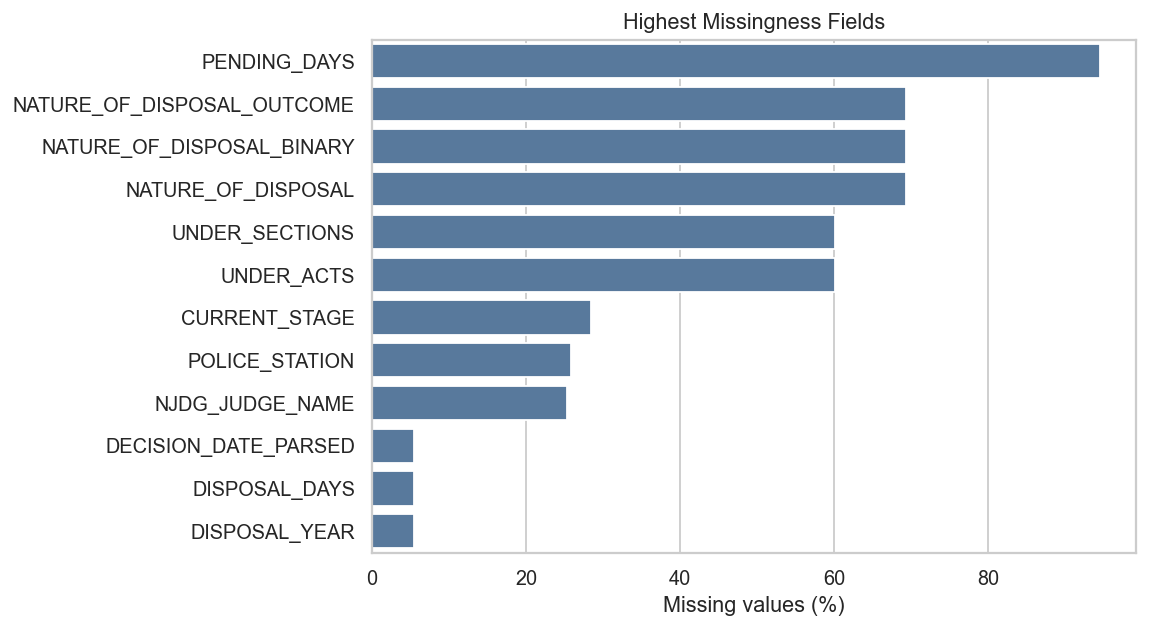

Saved figure: outputs/figures/01_missingness_top_fields.png


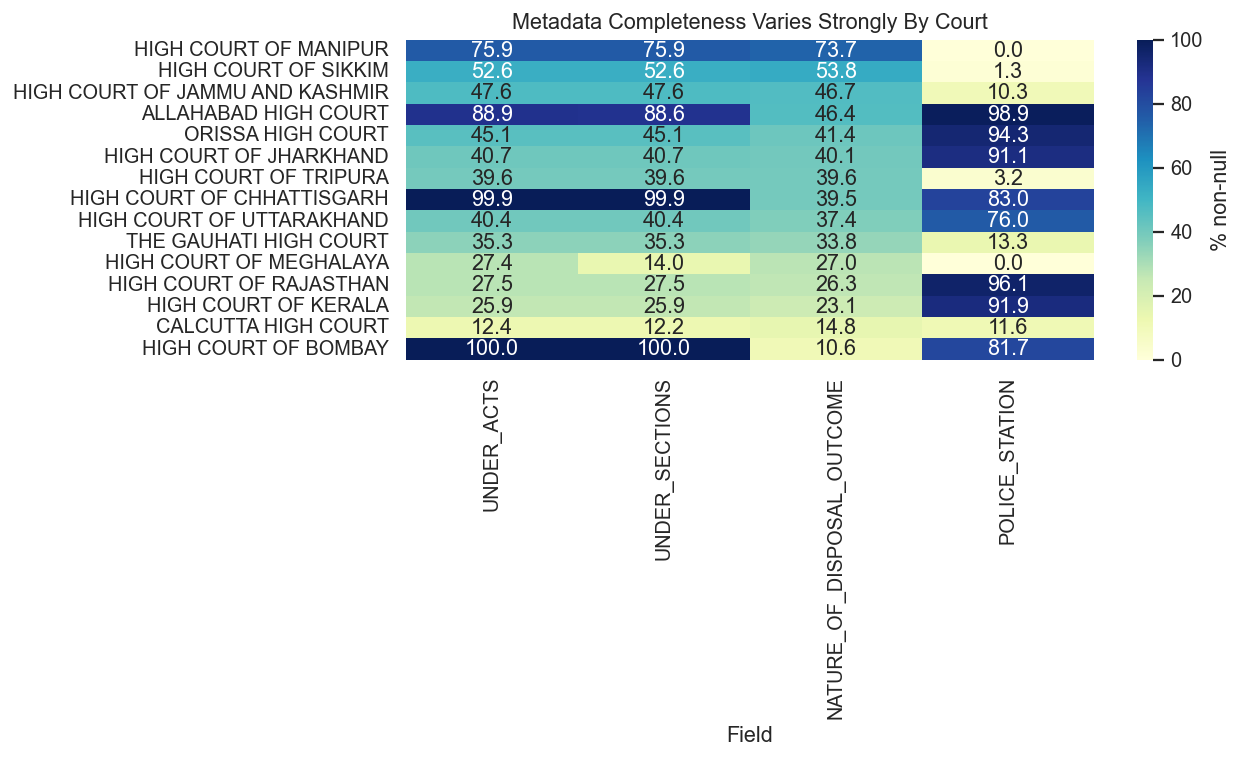

Saved figure: outputs/figures/01_court_metadata_completeness.png


In [6]:
missing_profile = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "field"})
)
table_out(missing_profile.head(20).round(2), "01_missing_profile_top20.csv", "Top 20 fields by missingness", index=False)

court_completeness = (
    df.groupby("NAME_OF_HIGH_COURT")
    [["UNDER_ACTS", "UNDER_SECTIONS", "NATURE_OF_DISPOSAL_OUTCOME", "POLICE_STATION"]]
    .apply(lambda x: x.notna().mean().mul(100))
    .round(1)
    .sort_values("NATURE_OF_DISPOSAL_OUTCOME", ascending=False)
)
table_out(court_completeness, "01_court_metadata_completeness.csv", "Metadata completeness by High Court")

plt.figure(figsize=(9, 5))
sns.barplot(data=missing_profile.head(12), x="missing_pct", y="field", color="#4C78A8")
plt.title("Highest Missingness Fields")
plt.xlabel("Missing values (%)")
plt.ylabel("")
save_current_fig("01_missingness_top_fields.png")

plt.figure(figsize=(10, 6))
sns.heatmap(court_completeness, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "% non-null"})
plt.title("Metadata Completeness Varies Strongly By Court")
plt.xlabel("Field")
plt.ylabel("")
save_current_fig("01_court_metadata_completeness.png")

In [7]:
def classify_act(value) -> str:
    if pd.isna(value):
        return "MISSING"
    text = str(value).upper()
    if text.strip() in {"", "---", "OTHER", "OTHER ACTS", "OTHER||", "NAN"}:
        return "OTHER_OR_UNSPECIFIED"
    if "POCSO" in text or "PROTECTION OF CHILDREN" in text:
        return "POCSO"
    if "NARCOTIC" in text or "PSYCHOTROPIC" in text or "NDPS" in text:
        return "NDPS"
    if "DOWRY" in text:
        return "DOWRY"
    if "ARMS" in text:
        return "ARMS"
    if "EXCISE" in text:
        return "EXCISE"
    if "INDIAN PENAL" in text or "I.P.C" in text or re.search(r"\bIPC\b", text):
        return "IPC"
    if "CRIMINAL PROCEDURE" in text or "CR.PC" in text or "CRPC" in text:
        return "CRPC"
    return "OTHER_SPECIFIED"


def classify_section(value) -> str:
    if pd.isna(value):
        return "MISSING"
    text = str(value).upper()
    if text.strip() in {"", "---", "NAN"}:
        return "MISSING_OR_UNSPECIFIED"
    compact = re.sub(r"\s+", "", text)
    if "438" in compact:
        return "SEC_438_ANTICIPATORY"
    if "439" in compact:
        return "SEC_439_REGULAR"
    if "302" in compact:
        return "SEC_302_MURDER"
    if "376" in compact:
        return "SEC_376_SEXUAL_OFFENCE"
    if "420" in compact:
        return "SEC_420_CHEATING"
    if "498A" in compact or "304B" in compact:
        return "MATRIMONIAL_DOWRY"
    if "307" in compact:
        return "SEC_307_ATTEMPT_MURDER"
    return "OTHER_SECTIONS"


df["ACT_GROUP"] = df["UNDER_ACTS"].map(classify_act)
df["SECTION_GROUP"] = df["UNDER_SECTIONS"].map(classify_section)

legal_metadata_summary = pd.DataFrame({
    "ACT_GROUP": df["ACT_GROUP"].value_counts(),
}).join(pd.DataFrame({"SECTION_GROUP": df["SECTION_GROUP"].value_counts()}), how="outer").fillna(0).astype(int)

table_out(legal_metadata_summary, "01_legal_metadata_groups.csv", "Cleaned legal metadata groups")

**Cleaned legal metadata groups**

,ACT_GROUP,SECTION_GROUP
ARMS,4998,0
CRPC,162843,0
DOWRY,3510,0
EXCISE,455,0
IPC,66141,0
MATRIMONIAL_DOWRY,0,8381
MISSING,557662,558063
MISSING_OR_UNSPECIFIED,0,1621
NDPS,3703,0
OTHER_OR_UNSPECIFIED,117275,0


Saved table: outputs/tables/01_legal_metadata_groups.csv


# Investigation 1 - Bail-Type Landscape

**Lead:** Tanishq Gupta

**Question:** How are regular bail, anticipatory bail, and cancellation cases distributed across courts, years, and case-type conventions?

This module uses the full dataset because `Mapped_Bail`, court, filing year, and case type are available for all records.

**Bail type distribution**

,Mapped_Bail,cases,share_pct
0,REGULAR BAIL,639099,68.880
1,ANTICIPATORY BAIL,283392,30.540
2,CANCELLATION,5405,0.580


Saved table: outputs/tables/02_bail_type_counts.csv


**Status mix within each bail type**

CURRENT_STATUS,Disposed,Pending
Mapped_Bail,,
ANTICIPATORY BAIL,92.120,7.880
CANCELLATION,65.830,34.170
REGULAR BAIL,95.820,4.180


Saved table: outputs/tables/02_status_mix_by_bail_type.csv


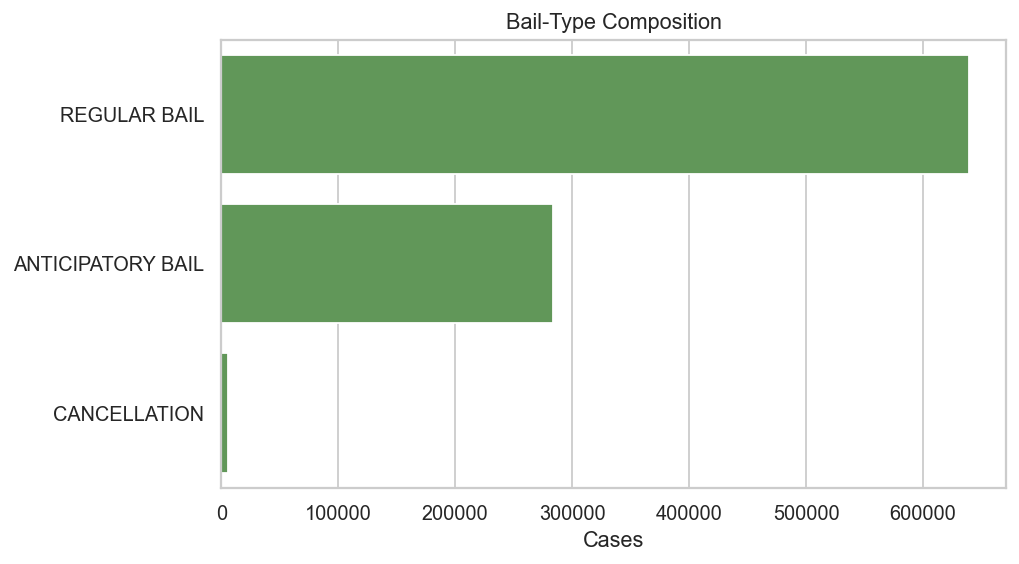

Saved figure: outputs/figures/02_bail_type_composition.png


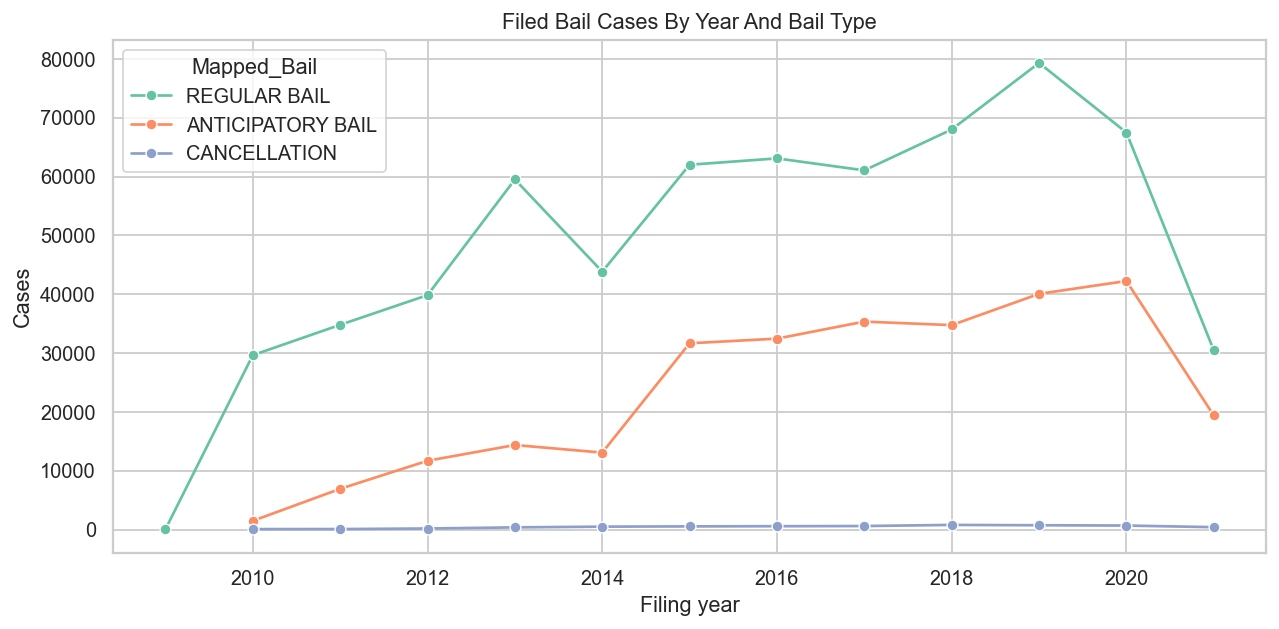

Saved figure: outputs/figures/02_filed_cases_by_year_bail_type.png


In [8]:
bail_counts = (
    df["Mapped_Bail"]
    .value_counts()
    .rename_axis("Mapped_Bail")
    .reset_index(name="cases")
)
bail_counts["share_pct"] = bail_counts["cases"] / len(df) * 100
table_out(bail_counts.round(2), "02_bail_type_counts.csv", "Bail type distribution", index=False)

status_mix = (
    pd.crosstab(df["Mapped_Bail"], df["CURRENT_STATUS"], normalize="index")
    .mul(100)
    .round(2)
)
table_out(status_mix, "02_status_mix_by_bail_type.csv", "Status mix within each bail type")

plt.figure(figsize=(8, 4.5))
sns.barplot(data=bail_counts, x="cases", y="Mapped_Bail", color="#59A14F")
plt.title("Bail-Type Composition")
plt.xlabel("Cases")
plt.ylabel("")
save_current_fig("02_bail_type_composition.png")

year_bail = (
    df.groupby(["FILED_YEAR", "Mapped_Bail"])
    .size()
    .reset_index(name="cases")
    .dropna(subset=["FILED_YEAR"])
)
plt.figure(figsize=(10, 5))
sns.lineplot(data=year_bail, x="FILED_YEAR", y="cases", hue="Mapped_Bail", marker="o")
plt.title("Filed Bail Cases By Year And Bail Type")
plt.xlabel("Filing year")
plt.ylabel("Cases")
save_current_fig("02_filed_cases_by_year_bail_type.png")

**Bail mix by High Court**

Mapped_Bail,ANTICIPATORY BAIL,CANCELLATION,REGULAR BAIL,TOTAL_CASES
NAME_OF_HIGH_COURT,,,,
ORISSA HIGH COURT,67.590,0.000,32.410,173769
HIGH COURT OF RAJASTHAN,0.000,0.740,99.260,171305
HIGH COURT OF JHARKHAND,36.960,0.000,63.040,155243
CALCUTTA HIGH COURT,0.000,0.000,100.000,113025
HIGH COURT OF KERALA,0.000,0.000,100.000,92061
THE GAUHATI HIGH COURT,55.530,0.000,44.470,86836
HIGH COURT OF BOMBAY,40.880,1.090,58.020,58850
HIGH COURT OF UTTARAKHAND,1.600,0.750,97.650,27167
ALLAHABAD HIGH COURT,61.590,12.780,25.640,25733


Saved table: outputs/tables/02_court_bail_mix_percent.csv


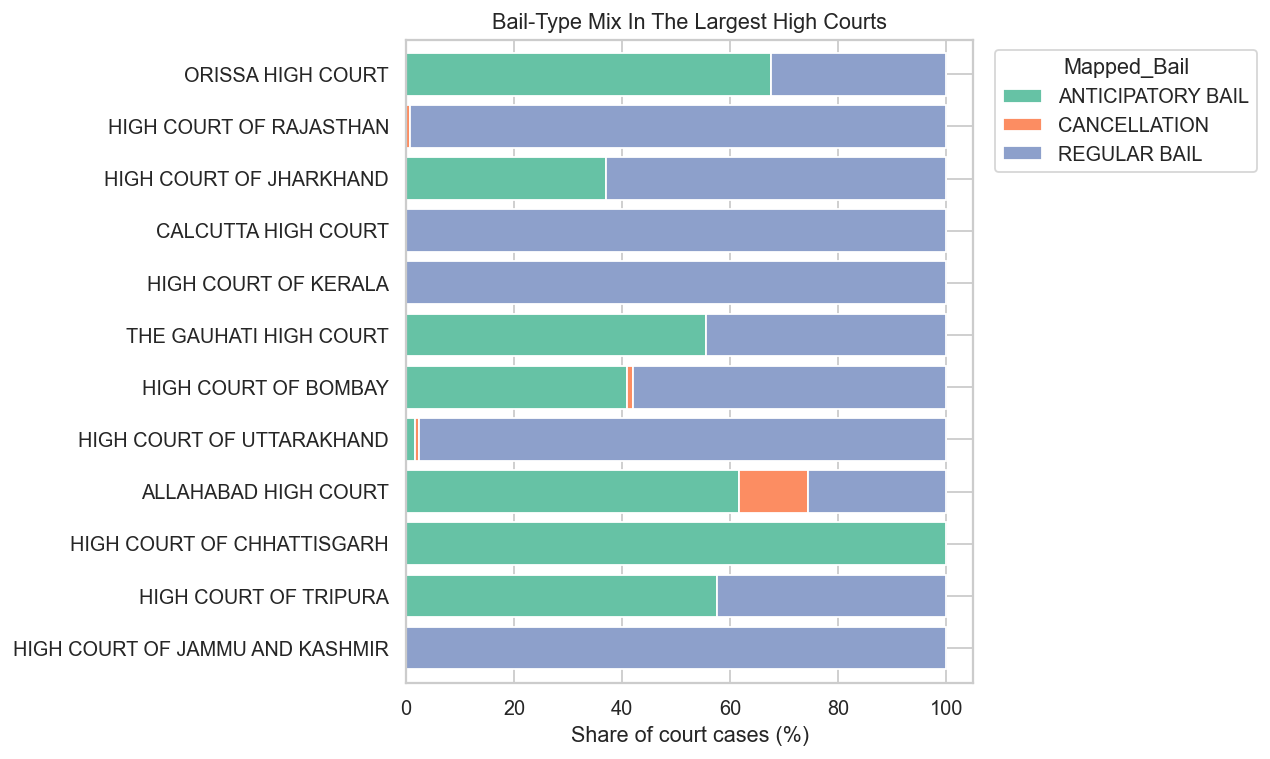

Saved figure: outputs/figures/02_largest_courts_bail_mix.png


**Top case-type groups by bail type**

,Mapped_Bail,CASE_TYPE_GROUP,cases,share_pct
4,ANTICIPATORY BAIL,ABLAPL,117449,41.440
0,ANTICIPATORY BAIL,A.B.A.,57372,20.240
1,ANTICIPATORY BAIL,AB,50734,17.900
2,ANTICIPATORY BAIL,ABA,24488,8.640
5,ANTICIPATORY BAIL,MCRCA,17493,6.170
3,ANTICIPATORY BAIL,ABAIL,15848,5.590
6,ANTICIPATORY BAIL,OTHER_CASE_TYPE,8,0.000
9,CANCELLATION,BAILC,3288,60.830
10,CANCELLATION,CRLBC,1270,23.500
7,CANCELLATION,ACB,644,11.910


Saved table: outputs/tables/02_top_case_types_by_bail.csv


In [9]:
court_bail_counts = (
    df.groupby(["NAME_OF_HIGH_COURT", "Mapped_Bail"])
    .size()
    .reset_index(name="cases")
)
court_totals = court_bail_counts.groupby("NAME_OF_HIGH_COURT")["cases"].transform("sum")
court_bail_counts["share_pct"] = court_bail_counts["cases"] / court_totals * 100

court_bail_pivot = (
    court_bail_counts.pivot(index="NAME_OF_HIGH_COURT", columns="Mapped_Bail", values="share_pct")
    .fillna(0)
    .round(2)
)
court_bail_pivot["TOTAL_CASES"] = df["NAME_OF_HIGH_COURT"].value_counts()
court_bail_pivot = court_bail_pivot.sort_values("TOTAL_CASES", ascending=False)
table_out(court_bail_pivot, "02_court_bail_mix_percent.csv", "Bail mix by High Court")

plot_mix = court_bail_pivot.drop(columns="TOTAL_CASES").head(12)
ax = plot_mix.plot(kind="barh", stacked=True, figsize=(10, 6), width=0.82)
ax.invert_yaxis()
ax.set_title("Bail-Type Mix In The Largest High Courts")
ax.set_xlabel("Share of court cases (%)")
ax.set_ylabel("")
ax.legend(title="Mapped_Bail", bbox_to_anchor=(1.02, 1), loc="upper left")
save_current_fig("02_largest_courts_bail_mix.png")

case_type_by_bail = (
    df.groupby(["Mapped_Bail", "CASE_TYPE_GROUP"])
    .size()
    .reset_index(name="cases")
)
case_type_by_bail["share_pct"] = (
    case_type_by_bail["cases"]
    / case_type_by_bail.groupby("Mapped_Bail")["cases"].transform("sum")
    * 100
)
top_case_by_bail = (
    case_type_by_bail.sort_values(["Mapped_Bail", "cases"], ascending=[True, False])
    .groupby("Mapped_Bail")
    .head(8)
    .round(2)
)
table_out(top_case_by_bail, "02_top_case_types_by_bail.csv", "Top case-type groups by bail type", index=False)

**Investigation 1 takeaway.** Bail type is not evenly distributed across courts. Some courts are almost entirely regular-bail heavy, while others record a much larger share of anticipatory bail. This means later delay and pendency comparisons must account for court composition and registry conventions.

Substantively, this matters because the analysis should not treat all bail cases as interchangeable. A court with mostly regular-bail filings and a court with mostly anticipatory-bail filings may show different disposal patterns even before any institutional delay is considered. The first investigation therefore establishes the core denominator for the rest of the project: every later comparison is interpreted through the joint lens of **court**, **bail type**, and **case-type convention**.

# Investigation 2 - Disposal Delay And Court Inequality

**Lead:** Kavish Jain

**Question:** Which courts and bail types take longer to dispose cases, and does the ranking change after adjusting for bail type, filing year, and case-type mix?

This module uses disposed cases with valid disposal days and excludes the small number of records where decision date is earlier than filing date.

In [10]:
disposed = df.loc[
    df["IS_DISPOSED"]
    & df["DISPOSAL_DAYS"].notna()
    & (df["DISPOSAL_DAYS"] >= 1)
    & ~df["DATE_ANOMALY_DECISION_BEFORE_FILED"]
].copy()

long_delay_p75 = float(disposed["DISPOSAL_DAYS"].quantile(0.75))
long_delay_p90 = float(disposed["DISPOSAL_DAYS"].quantile(0.90))
disposed["LONG_DELAY_P75"] = disposed["DISPOSAL_DAYS"] > long_delay_p75
disposed["VERY_LONG_DELAY_P90"] = disposed["DISPOSAL_DAYS"] > long_delay_p90

print(f"Disposed analytical cohort: {len(disposed):,}")
print(f"Long-delay threshold p75: > {long_delay_p75:.0f} days")
print(f"Very-long-delay threshold p90: > {long_delay_p90:.0f} days")

delay_by_bail = (
    disposed.groupby("Mapped_Bail")["DISPOSAL_DAYS"]
    .agg(cases="count", mean_days="mean", median_days="median",
         p75_days=lambda s: s.quantile(0.75), p90_days=lambda s: s.quantile(0.90),
         p99_days=lambda s: s.quantile(0.99))
    .round(2)
    .sort_values("median_days", ascending=False)
)
table_out(delay_by_bail, "03_delay_by_bail_type.csv", "Disposal-time distribution by bail type")

court_delay = (
    disposed.groupby("NAME_OF_HIGH_COURT")["DISPOSAL_DAYS"]
    .agg(cases="count", median_days="median", p75_days=lambda s: s.quantile(0.75),
         p90_days=lambda s: s.quantile(0.90), mean_days="mean")
    .round(2)
    .sort_values("median_days", ascending=False)
)
table_out(court_delay, "03_court_delay_distribution.csv", "Disposal-time distribution by High Court")

Disposed analytical cohort: 876,950
Long-delay threshold p75: > 63 days
Very-long-delay threshold p90: > 140 days


**Disposal-time distribution by bail type**

,cases,mean_days,median_days,p75_days,p90_days,p99_days
Mapped_Bail,,,,,,
CANCELLATION,3558,526.870,267.500,809.750,"1,556.100","2,378.010"
ANTICIPATORY BAIL,261041,76.880,37.000,86.000,175.000,528.000
REGULAR BAIL,612351,71.800,23.000,54.000,118.000,"1,330.500"


Saved table: outputs/tables/03_delay_by_bail_type.csv


**Disposal-time distribution by High Court**

,cases,median_days,p75_days,p90_days,mean_days
NAME_OF_HIGH_COURT,,,,,
HIGH COURT OF JAMMU AND KASHMIR,1792,156.000,486.500,"1,566.300",418.870
HIGH COURT OF MANIPUR,430,78.000,312.500,729.600,220.400
HIGH COURT OF JHARKHAND,151307,51.000,95.000,157.000,73.800
HIGH COURT OF BOMBAY,47725,43.000,110.000,215.000,85.120
HIGH COURT OF CHHATTISGARH,17492,43.000,80.000,123.900,58.920
ORISSA HIGH COURT,158077,42.000,102.000,225.000,88.530
HIGH COURT OF UTTARAKHAND,26445,28.000,84.000,182.000,72.510
THE GAUHATI HIGH COURT,86683,24.000,42.000,76.000,52.880
HIGH COURT OF RAJASTHAN,168366,17.000,39.000,92.000,108.590


Saved table: outputs/tables/03_court_delay_distribution.csv


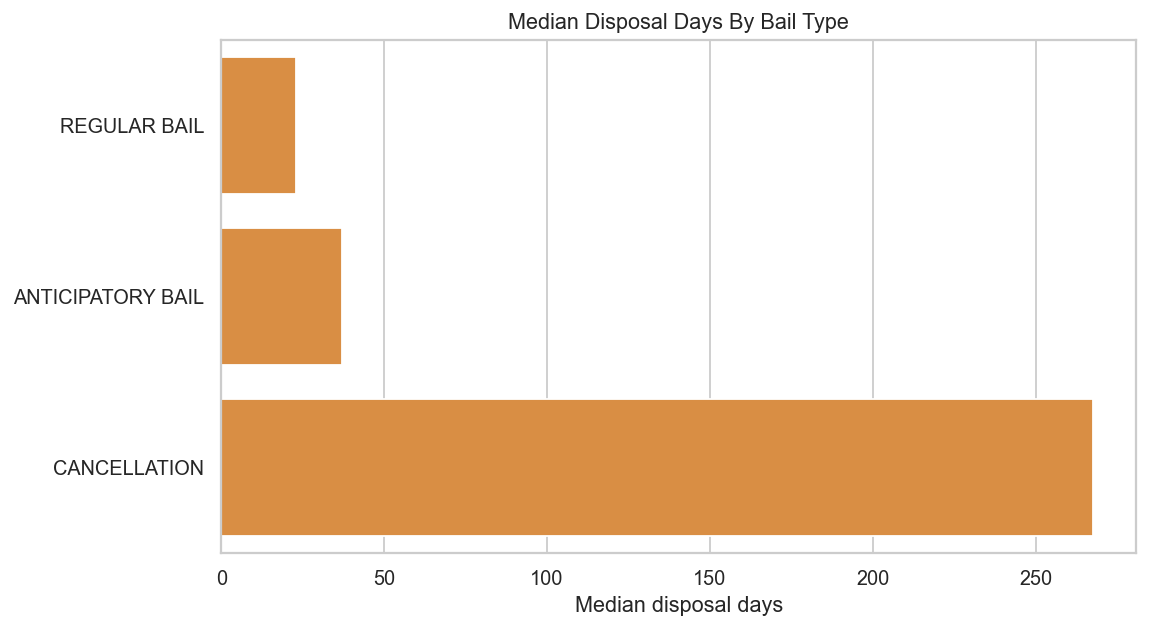

Saved figure: outputs/figures/03_median_delay_by_bail_type.png


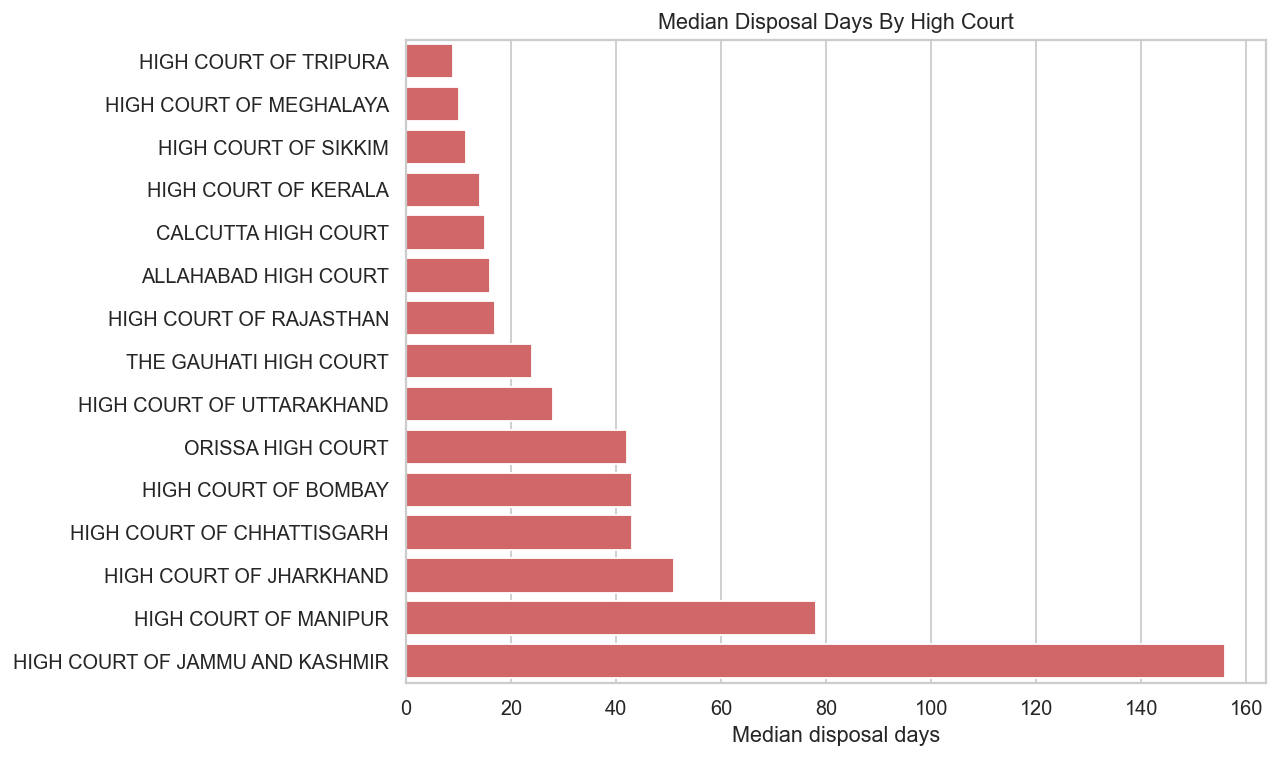

Saved figure: outputs/figures/03_median_delay_by_court.png


In [11]:
plt.figure(figsize=(9, 5))
plot_delay = delay_by_bail.reset_index().sort_values("median_days")
sns.barplot(data=plot_delay, x="median_days", y="Mapped_Bail", color="#F28E2B")
plt.title("Median Disposal Days By Bail Type")
plt.xlabel("Median disposal days")
plt.ylabel("")
save_current_fig("03_median_delay_by_bail_type.png")

plt.figure(figsize=(10, 6))
court_plot = court_delay.reset_index().sort_values("median_days", ascending=True)
sns.barplot(data=court_plot, x="median_days", y="NAME_OF_HIGH_COURT", color="#E15759")
plt.title("Median Disposal Days By High Court")
plt.xlabel("Median disposal days")
plt.ylabel("")
save_current_fig("03_median_delay_by_court.png")

**Adjusted court delay index**

,cases,observed_median_days,adjusted_delay_index,long_delay_rate_p75,very_long_delay_rate_p90
NAME_OF_HIGH_COURT,,,,,
HIGH COURT OF JAMMU AND KASHMIR,1792,156.000,397.550,67.910,52.120
HIGH COURT OF MANIPUR,430,78.000,233.410,53.020,39.770
HIGH COURT OF JHARKHAND,151307,51.000,192.310,41.650,12.940
ORISSA HIGH COURT,158077,42.000,123.330,36.630,17.450
HIGH COURT OF CHHATTISGARH,17492,43.000,115.220,34.360,7.810
HIGH COURT OF UTTARAKHAND,26445,28.000,113.330,31.400,14.080
HIGH COURT OF BOMBAY,47725,43.000,93.880,39.350,18.890
THE GAUHATI HIGH COURT,86683,24.000,90.000,13.320,3.990
HIGH COURT OF RAJASTHAN,168366,17.000,75.000,15.060,6.750


Saved table: outputs/tables/03_adjusted_court_delay_index.csv


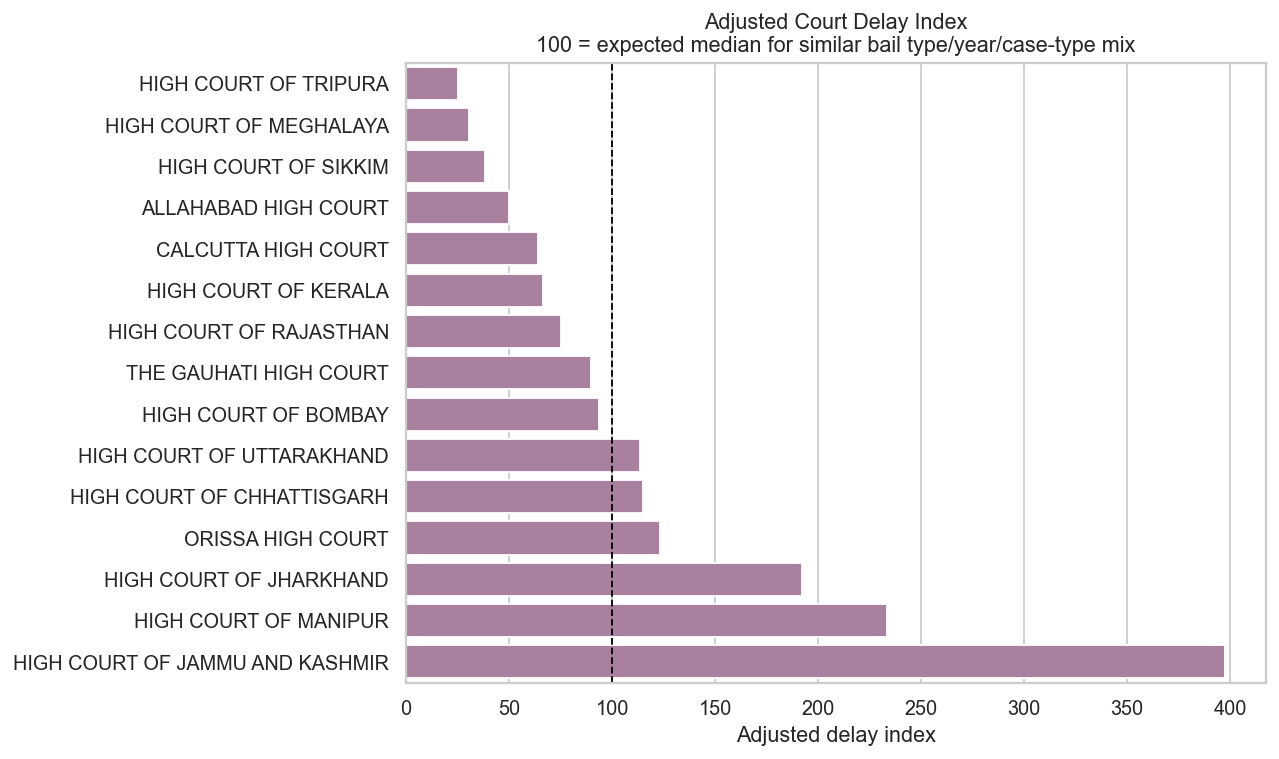

Saved figure: outputs/figures/03_adjusted_court_delay_index.png


In [12]:
# Adjustment without external modelling dependencies:
# Compare each case's observed disposal days to an expected median for similar
# bail type, filing year, and case type. Because many case-type labels are
# court-specific, we only use the case-type stratum when it spans at least
# three courts and 100 cases; otherwise we fall back to bail type + year.
strata_cols = ["Mapped_Bail", "FILED_YEAR", "CASE_TYPE_GROUP"]
stratum_stats = (
    disposed.groupby(strata_cols)
    .agg(
        EXPECTED_STRATUM_MEDIAN=("DISPOSAL_DAYS", "median"),
        STRATUM_CASES=("DISPOSAL_DAYS", "size"),
        STRATUM_COURTS=("NAME_OF_HIGH_COURT", "nunique"),
    )
    .reset_index()
)
fallback_stats = (
    disposed.groupby(["Mapped_Bail", "FILED_YEAR"])["DISPOSAL_DAYS"]
    .median()
    .rename("EXPECTED_BAIL_YEAR_MEDIAN")
    .reset_index()
)
disposed_adj = disposed.merge(stratum_stats, on=strata_cols, how="left")
disposed_adj = disposed_adj.merge(fallback_stats, on=["Mapped_Bail", "FILED_YEAR"], how="left")
global_median = disposed["DISPOSAL_DAYS"].median()
use_specific_stratum = (
    disposed_adj["STRATUM_CASES"].ge(100)
    & disposed_adj["STRATUM_COURTS"].ge(3)
)
disposed_adj["EXPECTED_MEDIAN_USED"] = np.where(
    use_specific_stratum,
    disposed_adj["EXPECTED_STRATUM_MEDIAN"],
    disposed_adj["EXPECTED_BAIL_YEAR_MEDIAN"],
)
disposed_adj["EXPECTED_MEDIAN_USED"] = disposed_adj["EXPECTED_MEDIAN_USED"].fillna(global_median)
disposed_adj["DELAY_RATIO"] = disposed_adj["DISPOSAL_DAYS"] / disposed_adj["EXPECTED_MEDIAN_USED"].clip(lower=1)
disposed_adj["ADJUSTMENT_LEVEL"] = np.where(use_specific_stratum, "bail+year+case_type", "bail+year fallback")

adjusted_court_delay = (
    disposed_adj.groupby("NAME_OF_HIGH_COURT")
    .agg(
        cases=("DISPOSAL_DAYS", "size"),
        observed_median_days=("DISPOSAL_DAYS", "median"),
        adjusted_delay_index=("DELAY_RATIO", lambda s: s.median() * 100),
        long_delay_rate_p75=("LONG_DELAY_P75", "mean"),
        very_long_delay_rate_p90=("VERY_LONG_DELAY_P90", "mean"),
    )
    .assign(
        long_delay_rate_p75=lambda x: x["long_delay_rate_p75"] * 100,
        very_long_delay_rate_p90=lambda x: x["very_long_delay_rate_p90"] * 100,
    )
    .round(2)
    .sort_values("adjusted_delay_index", ascending=False)
)
table_out(adjusted_court_delay, "03_adjusted_court_delay_index.csv", "Adjusted court delay index")

plt.figure(figsize=(10, 6))
adj_plot = adjusted_court_delay.reset_index().sort_values("adjusted_delay_index", ascending=True)
sns.barplot(data=adj_plot, x="adjusted_delay_index", y="NAME_OF_HIGH_COURT", color="#B07AA1")
plt.axvline(100, color="black", linewidth=1, linestyle="--")
plt.title("Adjusted Court Delay Index\n100 = expected median for similar bail type/year/case-type mix")
plt.xlabel("Adjusted delay index")
plt.ylabel("")
save_current_fig("03_adjusted_court_delay_index.png")

### 2a. Bootstrap Confidence Intervals For The Adjusted Court Delay Index

The adjusted index is a single number per court. To convey how stable that number is given each court's sample size, we resample each court's case-level `DELAY_RATIO` with replacement and report the 2.5th and 97.5th percentile of the bootstrapped median. This converts the descriptive index into an inferential statement: courts whose 95% CI does not overlap 100 are unlikely to have a typical case mix-adjusted disposal time equal to the all-court expectation under random sampling.

**Adjusted court delay index with bootstrap 95% confidence intervals**

,cases,adjusted_index_point,ci_low_2_5,ci_high_97_5,ci_excludes_100
NAME_OF_HIGH_COURT,,,,,
HIGH COURT OF JAMMU AND KASHMIR,1792,397.550,354.790,433.280,True
HIGH COURT OF MANIPUR,430,233.410,155.560,300.000,True
HIGH COURT OF JHARKHAND,151307,192.310,189.130,195.650,True
ORISSA HIGH COURT,158077,123.330,121.740,125.000,True
HIGH COURT OF CHHATTISGARH,17492,115.220,113.040,116.670,True
HIGH COURT OF UTTARAKHAND,26445,113.330,109.520,116.670,True
HIGH COURT OF BOMBAY,47725,93.880,91.840,95.950,True
THE GAUHATI HIGH COURT,86683,90.000,87.800,90.910,True
HIGH COURT OF RAJASTHAN,168366,75.000,73.080,76.190,True


Saved table: outputs/tables/03_adjusted_court_delay_bootstrap_ci.csv


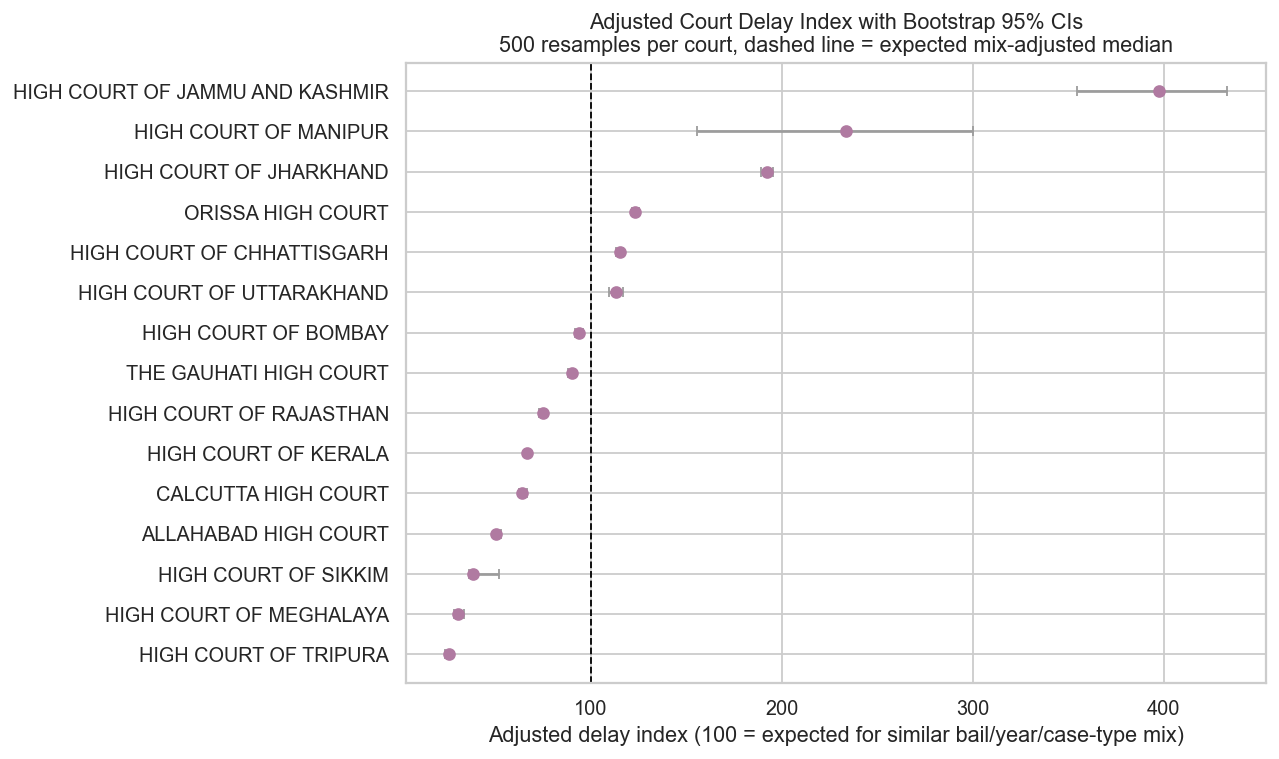

Saved figure: outputs/figures/03_adjusted_court_delay_bootstrap_ci.png
Bootstrap iterations per court: 500
Courts profiled: 15
Courts whose 95% CI excludes 100: 15 of 15


In [13]:
bootstrap_iters = 500
boot_rng = np.random.default_rng(RANDOM_SEED)

bootstrap_records = []
for court_name, court_group in disposed_adj.groupby("NAME_OF_HIGH_COURT"):
    ratios = court_group["DELAY_RATIO"].dropna().to_numpy()
    if len(ratios) < 30:
        continue
    n = len(ratios)
    sample_n = int(min(n, 20000))
    boot_medians = np.empty(bootstrap_iters)
    for i in range(bootstrap_iters):
        idx = boot_rng.integers(0, n, size=sample_n)
        boot_medians[i] = np.median(ratios[idx])
    point_estimate = float(np.median(ratios) * 100)
    ci_low = float(np.quantile(boot_medians, 0.025) * 100)
    ci_high = float(np.quantile(boot_medians, 0.975) * 100)
    bootstrap_records.append({
        "NAME_OF_HIGH_COURT": court_name,
        "cases": int(n),
        "adjusted_index_point": point_estimate,
        "ci_low_2_5": ci_low,
        "ci_high_97_5": ci_high,
        "ci_excludes_100": (ci_low > 100) or (ci_high < 100),
    })

bootstrap_court_index = (
    pd.DataFrame(bootstrap_records)
    .set_index("NAME_OF_HIGH_COURT")
    .round(2)
    .sort_values("adjusted_index_point", ascending=False)
)
table_out(
    bootstrap_court_index,
    "03_adjusted_court_delay_bootstrap_ci.csv",
    "Adjusted court delay index with bootstrap 95% confidence intervals",
)

plt.figure(figsize=(10, 6))
plot_df = bootstrap_court_index.reset_index().sort_values("adjusted_index_point", ascending=True)
err_low = (plot_df["adjusted_index_point"] - plot_df["ci_low_2_5"]).clip(lower=0)
err_high = (plot_df["ci_high_97_5"] - plot_df["adjusted_index_point"]).clip(lower=0)
plt.errorbar(
    plot_df["adjusted_index_point"], plot_df["NAME_OF_HIGH_COURT"],
    xerr=[err_low, err_high], fmt="o", color="#B07AA1",
    ecolor="#9C9C9C", capsize=3,
)
plt.axvline(100, color="black", linestyle="--", linewidth=1)
plt.title("Adjusted Court Delay Index with Bootstrap 95% CIs\n500 resamples per court, dashed line = expected mix-adjusted median")
plt.xlabel("Adjusted delay index (100 = expected for similar bail/year/case-type mix)")
plt.ylabel("")
save_current_fig("03_adjusted_court_delay_bootstrap_ci.png")

print(f"Bootstrap iterations per court: {bootstrap_iters}")
print(f"Courts profiled: {len(bootstrap_court_index)}")
print(f"Courts whose 95% CI excludes 100: {int(bootstrap_court_index['ci_excludes_100'].sum())} of {len(bootstrap_court_index)}")

**Investigation 2 takeaway.** Raw court rankings are informative but incomplete because courts handle different bail-type and case-type mixes. The adjusted delay index compares each court to cases with similar filing year, bail type, and case type, making the court-level comparison more balanced. Bootstrap 95% CIs (500 resamples per court, generated above) confirm that the high-delay courts at the top of the table are not a small-sample artifact: their CIs sit well above the 100 reference line.

The adjusted index is not a causal estimate of court efficiency. It is a disciplined descriptive benchmark: values above 100 mean that the court's median case took longer than expected relative to comparable bail-type and filing-year groups, while values below 100 mean faster-than-expected disposal. This level of interpretation fits the available data because the dataset lacks judge-level reasoning, offence facts, custody period, and litigant characteristics. The value of the index is that it avoids ranking courts purely on raw medians when their case mixes differ sharply.

# Investigation 3 - Long-Delay Risk Prediction

**Lead:** Pranav Pipariya

**Question:** Using information plausibly available near filing, can we estimate whether a disposed case is likely to take unusually long?

The model predicts whether `DISPOSAL_DAYS` exceeds the disposed-cohort p75 threshold. A p90 model is included as a robustness check. The model intentionally excludes leakage variables such as `DECISION_DATE`, `DISPOSAL_DAYS`, `PENDING_DAYS`, `CURRENT_STATUS`, and disposal-outcome fields.

Methodological safeguards for this investigation:

- The target is a measured processing outcome, not a bail-grant or bail-rejection decision.
- Predictors are limited to fields plausibly available near filing, so the model does not learn from the decision date, final status, disposal duration, pending duration, or disposal outcome.
- Training and testing are separated by filing year rather than by a random split, which better reflects how a historical model would be evaluated on later cases.
- Results are compared with both a global-rate baseline and a court+bail baseline, so the model is not overclaimed when simpler historical grouping explains much of the signal.
- Coefficients, calibration, and lift are reported because the goal is transparent empirical interpretation rather than a black-box prediction score.

In [14]:
model_features = [
    "NAME_OF_HIGH_COURT", "Mapped_Bail", "CASE_TYPE_GROUP",
    "FILED_YEAR", "FILED_MONTH", "ACT_GROUP", "SECTION_GROUP",
]
leakage_fields = {
    "CURRENT_STATUS", "DECISION_DATE", "DECISION_DATE_PARSED",
    "DISPOSAL_DAYS", "PENDING_DAYS", "NATURE_OF_DISPOSAL",
    "NATURE_OF_DISPOSAL_OUTCOME", "NATURE_OF_DISPOSAL_BINARY",
    "LAST_SYNC_TIME", "LAST_SYNC_TIME_PARSED",
}
assert not leakage_fields.intersection(model_features), "Leakage field included in model features."

model_source = disposed.dropna(subset=["FILED_YEAR", "FILED_MONTH"]).copy()
model_source["FILED_YEAR"] = model_source["FILED_YEAR"].astype(int).astype(str)
model_source["FILED_MONTH"] = model_source["FILED_MONTH"].astype(int).astype(str).str.zfill(2)

train_pool = model_source[model_source["FILED_YEAR"].astype(int) <= 2018]
test_pool = model_source[model_source["FILED_YEAR"].astype(int) >= 2019]

train_sample = train_pool.sample(n=min(120_000, len(train_pool)), random_state=RANDOM_SEED)
test_sample = test_pool.sample(n=min(80_000, len(test_pool)), random_state=RANDOM_SEED)

print(f"Train pool: {len(train_pool):,}; train sample: {len(train_sample):,}")
print(f"Test pool: {len(test_pool):,}; test sample: {len(test_sample):,}")
print(f"Features: {model_features}")

Train pool: 641,096; train sample: 120,000
Test pool: 235,854; test sample: 80,000
Features: ['NAME_OF_HIGH_COURT', 'Mapped_Bail', 'CASE_TYPE_GROUP', 'FILED_YEAR', 'FILED_MONTH', 'ACT_GROUP', 'SECTION_GROUP']


In [15]:
def make_design_matrix(frame: pd.DataFrame, feature_cols, columns=None) -> pd.DataFrame:
    feature_frame = frame[feature_cols].copy()
    for col in feature_cols:
        feature_frame[col] = feature_frame[col].astype("string").fillna("MISSING")
    X = pd.get_dummies(feature_frame, columns=feature_cols, dtype=np.float32)
    if columns is not None:
        X = X.reindex(columns=columns, fill_value=0.0)
    return X


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -35, 35)))


def fit_logistic_numpy(X: np.ndarray, y: np.ndarray, lr=0.12, l2=0.002, n_iter=140):
    beta = np.zeros(X.shape[1], dtype=np.float64)
    losses = []
    for i in range(n_iter):
        pred = sigmoid(X @ beta)
        reg = l2 * np.r_[0.0, beta[1:]]
        grad = (X.T @ (pred - y)) / len(y) + reg
        beta -= lr * grad
        if i in {0, 9, 24, 49, 99, n_iter - 1}:
            eps = 1e-9
            loss = -np.mean(y * np.log(pred + eps) + (1 - y) * np.log(1 - pred + eps))
            loss += 0.5 * l2 * np.sum(beta[1:] ** 2)
            losses.append({"iteration": i + 1, "loss": loss})
    return beta, pd.DataFrame(losses)


def standardize_train_test(X_train_df: pd.DataFrame, X_test_df: pd.DataFrame):
    X_train = X_train_df.to_numpy(dtype=np.float64)
    X_test = X_test_df.to_numpy(dtype=np.float64)
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1.0
    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    X_train_aug = np.c_[np.ones(len(X_train_std)), X_train_std]
    X_test_aug = np.c_[np.ones(len(X_test_std)), X_test_std]
    return X_train_aug, X_test_aug, mean, std


def auc_rank(y_true, score):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.nan
    order = np.argsort(score)
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(1, len(score) + 1)
    return (ranks[y_true == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


def metric_summary(y_true, proba, threshold):
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba)
    pred = (proba >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    return {
        "n": len(y_true),
        "event_rate": y_true.mean(),
        "threshold": threshold,
        "accuracy": (tp + tn) / len(y_true),
        "precision": tp / (tp + fp) if (tp + fp) else np.nan,
        "recall": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "brier": np.mean((proba - y_true) ** 2),
        "auc_rank": auc_rank(y_true, proba),
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }


def fit_and_evaluate_model(target_col: str, label: str):
    X_train_df = make_design_matrix(train_sample, model_features)
    X_test_df = make_design_matrix(test_sample, model_features, columns=X_train_df.columns)
    X_train_aug, X_test_aug, mean, std = standardize_train_test(X_train_df, X_test_df)
    y_train = train_sample[target_col].astype(int).to_numpy()
    y_test = test_sample[target_col].astype(int).to_numpy()

    beta, losses = fit_logistic_numpy(X_train_aug, y_train)
    p_train = sigmoid(X_train_aug @ beta)
    p_test = sigmoid(X_test_aug @ beta)
    threshold = float(y_train.mean())

    global_baseline = np.repeat(y_train.mean(), len(y_test))
    group_rates = (
        train_sample.assign(target=y_train)
        .groupby(["NAME_OF_HIGH_COURT", "Mapped_Bail"])["target"]
        .mean()
    )
    fallback = float(y_train.mean())
    group_baseline = [
        group_rates.get((row["NAME_OF_HIGH_COURT"], row["Mapped_Bail"]), fallback)
        for _, row in test_sample.iterrows()
    ]
    group_baseline = np.asarray(group_baseline)

    metrics = pd.DataFrame([
        {"model": f"{label} logistic", **metric_summary(y_test, p_test, threshold)},
        {"model": f"{label} global baseline", **metric_summary(y_test, global_baseline, threshold)},
        {"model": f"{label} court+bail baseline", **metric_summary(y_test, group_baseline, threshold)},
    ])

    coef = pd.DataFrame({
        "feature": ["INTERCEPT"] + list(X_train_df.columns),
        "coefficient": beta,
    })
    coef["abs_coefficient"] = coef["coefficient"].abs()
    coef = coef.sort_values("abs_coefficient", ascending=False)

    calibration = pd.DataFrame({"y_true": y_test, "proba": p_test})
    calibration["risk_bucket"] = pd.qcut(calibration["proba"], q=10, duplicates="drop")
    calibration_summary = (
        calibration.groupby("risk_bucket")
        .agg(n=("y_true", "size"), mean_predicted_risk=("proba", "mean"), observed_event_rate=("y_true", "mean"))
        .reset_index()
    )

    artifacts = {
        "columns": X_train_df.columns,
        "mean": mean,
        "std": std,
        "beta": beta,
        "threshold": threshold,
        "p_test": p_test,
        "y_test": y_test,
        "losses": losses,
        "metrics": metrics,
        "coef": coef,
        "calibration": calibration_summary,
    }
    return artifacts

In [16]:
model_p75 = fit_and_evaluate_model("LONG_DELAY_P75", "p75 long-delay")
model_p90 = fit_and_evaluate_model("VERY_LONG_DELAY_P90", "p90 very-long-delay")

model_metrics = pd.concat([model_p75["metrics"], model_p90["metrics"]], ignore_index=True)
metric_cols = ["event_rate", "threshold", "accuracy", "precision", "recall", "specificity", "brier", "auc_rank"]
model_metrics_display = model_metrics.copy()
model_metrics_display[metric_cols] = model_metrics_display[metric_cols].round(3)
table_out(model_metrics_display, "04_model_performance.csv", "Temporal test-set model performance", index=False)

table_out(model_p75["losses"].round(4), "04_p75_training_loss.csv", "p75 model training loss checkpoints", index=False)
table_out(model_p75["coef"].head(20).round(4), "04_p75_top_coefficients.csv", "Largest p75 model coefficients", index=False)
table_out(model_p75["calibration"].round(3), "04_p75_calibration_by_decile.csv", "p75 model calibration by predicted-risk decile", index=False)

def risk_lift_table(model_artifacts, label):
    y = np.asarray(model_artifacts["y_test"]).astype(int)
    p = np.asarray(model_artifacts["p_test"])
    base = y.mean()
    rows = []
    for share in [0.10, 0.20, 0.30]:
        cutoff = np.quantile(p, 1 - share)
        selected = p >= cutoff
        rows.append({
            "target": label,
            "selected_highest_risk_share": share,
            "selected_cases": int(selected.sum()),
            "observed_event_rate_selected": y[selected].mean(),
            "overall_event_rate": base,
            "lift_vs_overall": y[selected].mean() / base if base else np.nan,
            "captured_events_share": y[selected].sum() / y.sum() if y.sum() else np.nan,
        })
    return pd.DataFrame(rows)


lift_summary = pd.concat([
    risk_lift_table(model_p75, "p75 long-delay"),
    risk_lift_table(model_p90, "p90 very-long-delay"),
], ignore_index=True)
table_out(lift_summary.round(3), "04_model_lift_summary.csv", "Risk concentration among highest-risk test cases", index=False)


def bootstrap_auc_ci(y_true, score, n_iter=400, seed=RANDOM_SEED):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    rng_local = np.random.default_rng(seed)
    n = len(y_true)
    boot_aucs = np.empty(n_iter)
    for i in range(n_iter):
        idx = rng_local.integers(0, n, size=n)
        if y_true[idx].sum() in (0, n):
            boot_aucs[i] = np.nan
            continue
        boot_aucs[i] = auc_rank(y_true[idx], score[idx])
    boot_aucs = boot_aucs[~np.isnan(boot_aucs)]
    return {
        "auc_point": float(auc_rank(y_true, score)),
        "auc_ci_low": float(np.quantile(boot_aucs, 0.025)),
        "auc_ci_high": float(np.quantile(boot_aucs, 0.975)),
        "n_iter": int(len(boot_aucs)),
    }


def baseline_court_bail_predictions(model_artifacts, train_frame, train_target):
    rates = (
        train_frame.assign(target=train_target)
        .groupby(["NAME_OF_HIGH_COURT", "Mapped_Bail"])["target"]
        .mean()
    )
    fallback = float(np.asarray(train_target).mean())
    test_keys = list(zip(test_sample["NAME_OF_HIGH_COURT"], test_sample["Mapped_Bail"]))
    return np.asarray([float(rates.get(k, fallback)) for k in test_keys])


auc_records = []
for label, artifacts, target_col in [
    ("p75 long-delay logistic", model_p75, "LONG_DELAY_P75"),
    ("p90 very-long-delay logistic", model_p90, "VERY_LONG_DELAY_P90"),
]:
    boot = bootstrap_auc_ci(artifacts["y_test"], artifacts["p_test"])
    auc_records.append({
        "model": label,
        "auc_point": round(boot["auc_point"], 4),
        "auc_ci_low_2_5": round(boot["auc_ci_low"], 4),
        "auc_ci_high_97_5": round(boot["auc_ci_high"], 4),
        "bootstrap_iterations": boot["n_iter"],
    })
    train_target = train_sample[target_col].astype(int).to_numpy()
    baseline_pred = baseline_court_bail_predictions(artifacts, train_sample, train_target)
    boot_baseline = bootstrap_auc_ci(artifacts["y_test"], baseline_pred)
    auc_records.append({
        "model": label.replace("logistic", "court+bail baseline"),
        "auc_point": round(boot_baseline["auc_point"], 4),
        "auc_ci_low_2_5": round(boot_baseline["auc_ci_low"], 4),
        "auc_ci_high_97_5": round(boot_baseline["auc_ci_high"], 4),
        "bootstrap_iterations": boot_baseline["n_iter"],
    })

auc_ci_table = pd.DataFrame(auc_records)
table_out(
    auc_ci_table,
    "04_model_auc_bootstrap_ci.csv",
    "Bootstrap 95% CIs for test-set AUC: logistic model vs court+bail baseline",
    index=False,
)
print("Bootstrap AUC 95% CIs (400 resamples each):")
display(auc_ci_table)

**Temporal test-set model performance**

,model,n,event_rate,threshold,accuracy,precision,recall,specificity,brier,auc_rank,tp,fp,tn,fn
0,p75 long-delay logistic,80000,0.240,0.254,0.556,0.305,0.659,0.524,0.194,0.637,12675,28940,31824,6561
1,p75 long-delay global baseline,80000,0.240,0.254,0.240,0.240,1.000,0.000,0.183,0.498,19236,60764,0,0
2,p75 long-delay court+bail baseline,80000,0.240,0.254,0.558,0.286,0.558,0.558,0.184,0.637,10738,26845,33919,8498
3,p90 very-long-delay logistic,80000,0.091,0.103,0.527,0.124,0.689,0.511,0.093,0.623,5022,35553,37157,2268
4,p90 very-long-delay global baseline,80000,0.091,0.103,0.091,0.091,1.000,0.000,0.083,0.499,7290,72710,0,0
5,p90 very-long-delay court+bail baseline,80000,0.091,0.103,0.617,0.139,0.615,0.617,0.084,0.619,4481,27845,44865,2809


Saved table: outputs/tables/04_model_performance.csv


**p75 model training loss checkpoints**

,iteration,loss
0,1,0.693
1,10,0.594
2,25,0.532
3,50,0.495
4,100,0.478
5,140,0.475


...

Saved table: outputs/tables/04_model_lift_summary.csv


**Bootstrap 95% CIs for test-set AUC: logistic model vs court+bail baseline**

,model,auc_point,auc_ci_low_2_5,auc_ci_high_97_5,bootstrap_iterations
0,p75 long-delay logistic,0.637,0.634,0.642,400
1,p75 long-delay court+bail baseline,0.637,0.633,0.641,400
2,p90 very-long-delay logistic,0.623,0.618,0.629,400
3,p90 very-long-delay court+bail baseline,0.619,0.613,0.626,400


Saved table: outputs/tables/04_model_auc_bootstrap_ci.csv
Bootstrap AUC 95% CIs (400 resamples each):


,model,auc_point,auc_ci_low_2_5,auc_ci_high_97_5,bootstrap_iterations
0,p75 long-delay logistic,0.637,0.634,0.642,400
1,p75 long-delay court+bail baseline,0.637,0.633,0.641,400
2,p90 very-long-delay logistic,0.623,0.618,0.629,400
3,p90 very-long-delay court+bail baseline,0.619,0.613,0.626,400


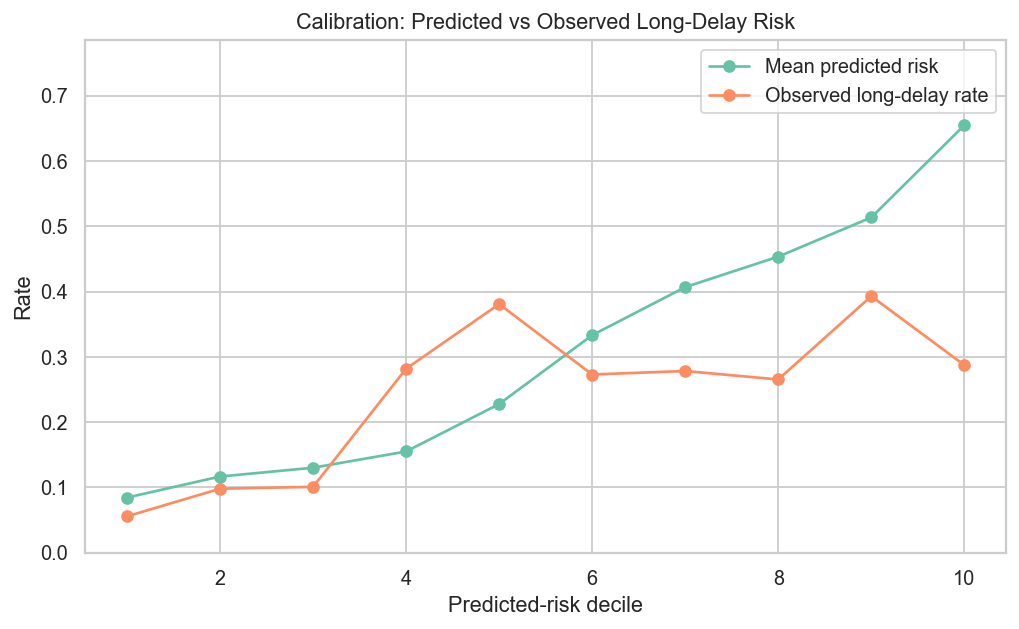

Saved figure: outputs/figures/04_p75_model_calibration.png


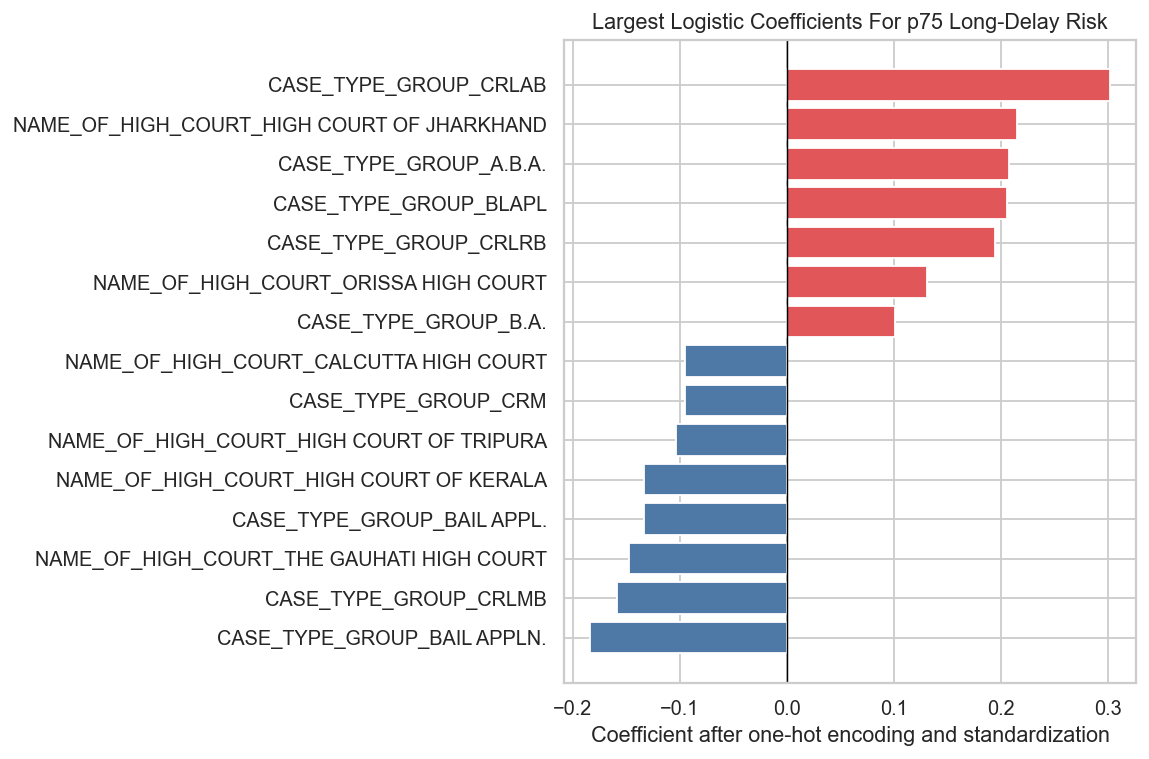

Saved figure: outputs/figures/04_p75_top_coefficients.png


In [17]:
plt.figure(figsize=(8, 5))
cal = model_p75["calibration"].copy()
cal["bucket"] = np.arange(1, len(cal) + 1)
plt.plot(cal["bucket"], cal["mean_predicted_risk"], marker="o", label="Mean predicted risk")
plt.plot(cal["bucket"], cal["observed_event_rate"], marker="o", label="Observed long-delay rate")
plt.title("Calibration: Predicted vs Observed Long-Delay Risk")
plt.xlabel("Predicted-risk decile")
plt.ylabel("Rate")
plt.ylim(0, max(cal["observed_event_rate"].max(), cal["mean_predicted_risk"].max()) * 1.2)
plt.legend()
save_current_fig("04_p75_model_calibration.png")

top_coef_plot = model_p75["coef"].query("feature != 'INTERCEPT'").head(15).copy()
top_coef_plot = top_coef_plot.sort_values("coefficient")
plt.figure(figsize=(9, 6))
colors = np.where(top_coef_plot["coefficient"] >= 0, "#E15759", "#4E79A7")
plt.barh(top_coef_plot["feature"], top_coef_plot["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Largest Logistic Coefficients For p75 Long-Delay Risk")
plt.xlabel("Coefficient after one-hot encoding and standardization")
plt.ylabel("")
save_current_fig("04_p75_top_coefficients.png")

**Investigation 3 takeaway.** The model is intentionally interpretable and dependency-free. Its purpose is not to determine legal merit; it estimates historical delay risk from court, bail type, case type, filing timing, and limited legal metadata. The baseline comparison is important: the court+bail historical-rate benchmark performs about as well as the fuller p75 model on AUC and slightly better on Brier score, and the bootstrap 95% AUC confidence intervals for the logistic and the baseline overlap, so the two are statistically indistinguishable. The prediction result is therefore best read as evidence that filing-stage metadata carries structured delay signal that a court-and-bail-type lookup already captures, rather than a claim that a more complex model is necessary or that historical risk should drive individual decisions.

The prediction section estimates **process risk** rather than legal outcome. The label is whether a disposed case crossed a long-delay threshold, not whether an accused person should receive bail. This keeps the model aligned with what the dataset can measure directly. The temporal train/test split also makes the validation more realistic: the model is trained on earlier filing years and evaluated on later ones.

The most useful interpretation is not just classification accuracy. For administrative decision support, the important question is whether the model concentrates risk: do the highest-risk predicted cases actually contain a higher share of delayed cases than the overall test set? The lift table answers that question and makes the prediction component more operationally meaningful.

# Investigation 4 - Pending Burden And COVID-Period Shift

**Lead:** Tushar Singh

**Question:** How did pending burden and filing/disposal patterns vary by court, bail type, and the 2020-2021 COVID-period window?

`CURRENT_STATUS` and `PENDING_DAYS` are scrape-date dependent. Pending analysis is therefore a snapshot of unresolved cases as recorded in the dataset, not a complete longitudinal survival estimate.

**Pending burden by High Court**

,total_cases,pending_cases,pending_rate,median_pending_days,p90_pending_days
NAME_OF_HIGH_COURT,,,,,
ALLAHABAD HIGH COURT,25733,12600,48.960,483.000,"1,117.000"
HIGH COURT OF BOMBAY,58850,11093,18.850,620.000,"1,163.000"
HIGH COURT OF JAMMU AND KASHMIR,2022,230,11.370,249.500,"1,299.700"
ORISSA HIGH COURT,173769,15692,9.030,300.000,625.000
HIGH COURT OF MANIPUR,449,19,4.230,701.000,"1,105.200"
HIGH COURT OF UTTARAKHAND,27167,722,2.660,296.000,632.000
HIGH COURT OF JHARKHAND,155243,3936,2.540,32.000,226.500
CALCUTTA HIGH COURT,113025,2509,2.220,"2,478.000","3,227.000"
HIGH COURT OF RAJASTHAN,171305,2939,1.720,72.000,351.000


Saved table: outputs/tables/05_pending_summary_by_court.csv


**Pending burden by bail type**

,total_cases,pending_cases,pending_rate,median_pending_days
Mapped_Bail,,,,
CANCELLATION,5405,1847,34.170,595.000
ANTICIPATORY BAIL,283392,22340,7.880,339.000
REGULAR BAIL,639099,26727,4.180,461.000


Saved table: outputs/tables/05_pending_summary_by_bail.csv


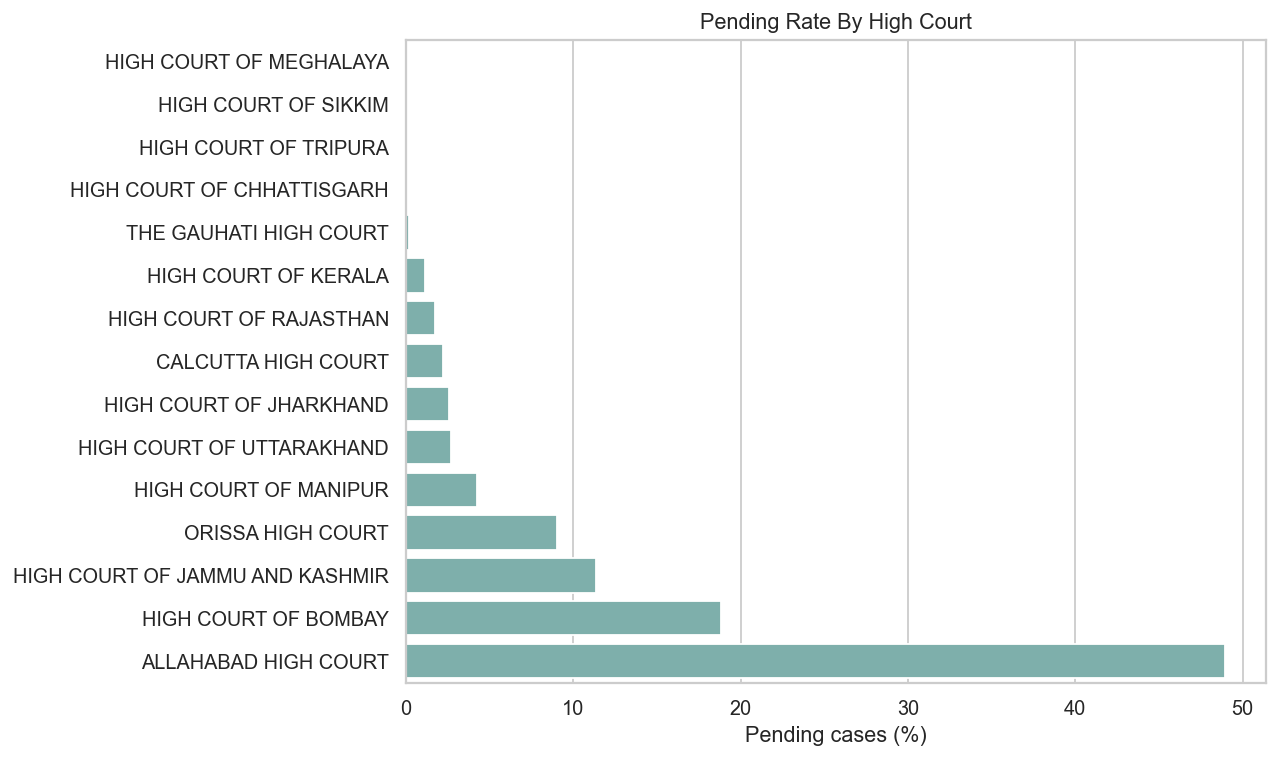

Saved figure: outputs/figures/05_pending_rate_by_court.png


In [18]:
pending_summary = (
    df.groupby("NAME_OF_HIGH_COURT")
    .agg(
        total_cases=("CNR_NUMBER", "size"),
        pending_cases=("IS_PENDING", "sum"),
        pending_rate=("IS_PENDING", "mean"),
        median_pending_days=("PENDING_DAYS", "median"),
        p90_pending_days=("PENDING_DAYS", lambda s: s.dropna().quantile(0.90) if s.notna().any() else np.nan),
    )
    .assign(pending_rate=lambda x: x["pending_rate"] * 100)
    .round(2)
    .sort_values("pending_rate", ascending=False)
)
table_out(pending_summary, "05_pending_summary_by_court.csv", "Pending burden by High Court")

pending_by_bail = (
    df.groupby("Mapped_Bail")
    .agg(
        total_cases=("CNR_NUMBER", "size"),
        pending_cases=("IS_PENDING", "sum"),
        pending_rate=("IS_PENDING", "mean"),
        median_pending_days=("PENDING_DAYS", "median"),
    )
    .assign(pending_rate=lambda x: x["pending_rate"] * 100)
    .round(2)
    .sort_values("pending_rate", ascending=False)
)
table_out(pending_by_bail, "05_pending_summary_by_bail.csv", "Pending burden by bail type")

plt.figure(figsize=(10, 6))
pending_plot = pending_summary.reset_index().sort_values("pending_rate", ascending=True)
sns.barplot(data=pending_plot, x="pending_rate", y="NAME_OF_HIGH_COURT", color="#76B7B2")
plt.title("Pending Rate By High Court")
plt.xlabel("Pending cases (%)")
plt.ylabel("")
save_current_fig("05_pending_rate_by_court.png")

**Pre-COVID vs COVID-window summary by bail type**

,PERIOD,Mapped_Bail,cases,pending_rate,median_pending_days,disposed_cases,median_disposal_days,p75_disposal_days
0,COVID-window filing years (2020-2021),ANTICIPATORY BAIL,61630,24.500,139.000,46531,31.000,62
1,COVID-window filing years (2020-2021),CANCELLATION,1067,69.920,160.000,321,111.000,247
2,COVID-window filing years (2020-2021),REGULAR BAIL,97947,16.530,147.000,81756,29.000,67
3,Pre-COVID filing years (2010-2019),ANTICIPATORY BAIL,221762,3.270,601.000,214510,38.000,93
4,Pre-COVID filing years (2010-2019),CANCELLATION,4338,25.380,932.000,3237,300.000,891
5,Pre-COVID filing years (2010-2019),REGULAR BAIL,541152,1.950,831.000,530595,22.000,52


Saved table: outputs/tables/05_period_summary_by_bail.csv


**Yearly filings and pending rate**

,FILED_YEAR,cases,pending_rate
0,2009,33,0.000
1,2010,31171,0.220
2,2011,41785,0.160
3,2012,51696,0.130
4,2013,74238,1.050
5,2014,57396,1.060
6,2015,94200,0.150
7,2016,96103,0.520
8,2017,96991,0.870
9,2018,103535,2.840


Saved table: outputs/tables/05_yearly_filing_and_pending_rate.csv


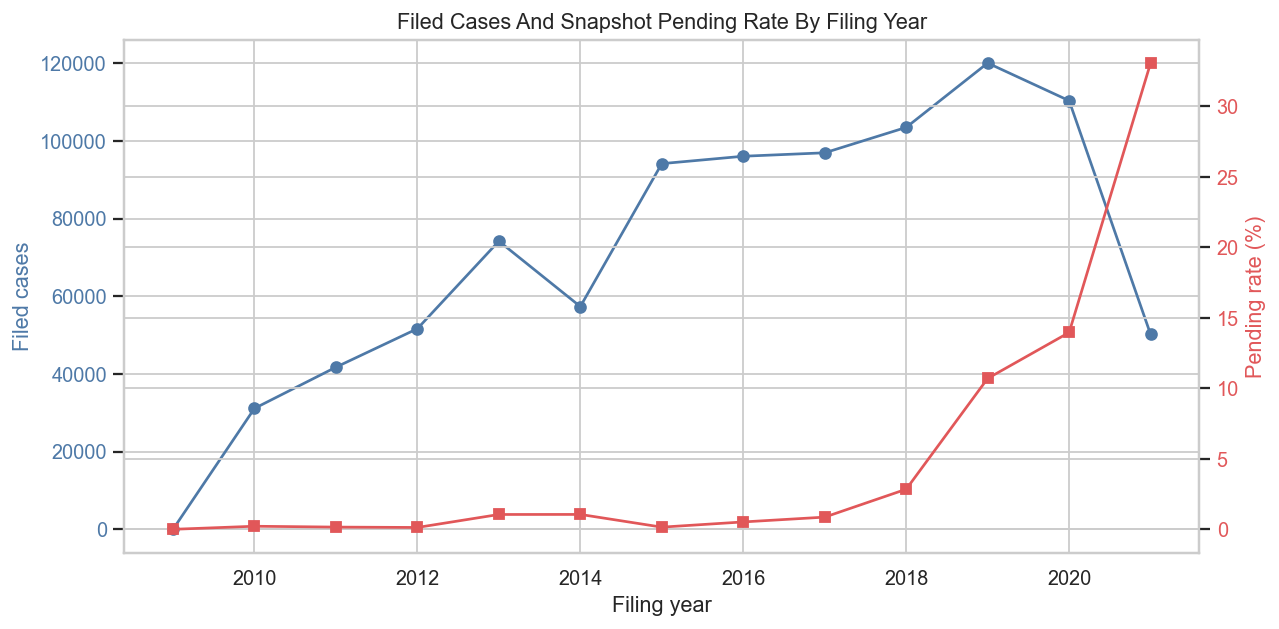

Saved figure: outputs/figures/05_yearly_filings_pending_rate.png


In [19]:
df["PERIOD"] = np.where(df["FILED_YEAR"] <= 2019, "Pre-COVID filing years (2010-2019)", "COVID-window filing years (2020-2021)")
disposed["PERIOD"] = np.where(disposed["FILED_YEAR"] <= 2019, "Pre-COVID filing years (2010-2019)", "COVID-window filing years (2020-2021)")

period_summary = (
    df.groupby(["PERIOD", "Mapped_Bail"])
    .agg(
        cases=("CNR_NUMBER", "size"),
        pending_rate=("IS_PENDING", "mean"),
        median_pending_days=("PENDING_DAYS", "median"),
    )
    .assign(pending_rate=lambda x: x["pending_rate"] * 100)
    .round(2)
    .reset_index()
)

period_disposal = (
    disposed.groupby(["PERIOD", "Mapped_Bail"])["DISPOSAL_DAYS"]
    .agg(disposed_cases="count", median_disposal_days="median", p75_disposal_days=lambda s: s.quantile(0.75))
    .round(2)
    .reset_index()
)

period_combined = period_summary.merge(period_disposal, on=["PERIOD", "Mapped_Bail"], how="left")
table_out(period_combined, "05_period_summary_by_bail.csv", "Pre-COVID vs COVID-window summary by bail type", index=False)

year_status = (
    df.groupby("FILED_YEAR")
    .agg(cases=("CNR_NUMBER", "size"), pending_rate=("IS_PENDING", "mean"))
    .assign(pending_rate=lambda x: x["pending_rate"] * 100)
    .reset_index()
)
table_out(year_status.round(2), "05_yearly_filing_and_pending_rate.csv", "Yearly filings and pending rate", index=False)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(year_status["FILED_YEAR"], year_status["cases"], marker="o", color="#4E79A7")
ax1.set_xlabel("Filing year")
ax1.set_ylabel("Filed cases", color="#4E79A7")
ax1.tick_params(axis="y", labelcolor="#4E79A7")
ax2 = ax1.twinx()
ax2.plot(year_status["FILED_YEAR"], year_status["pending_rate"], marker="s", color="#E15759")
ax2.set_ylabel("Pending rate (%)", color="#E15759")
ax2.tick_params(axis="y", labelcolor="#E15759")
plt.title("Filed Cases And Snapshot Pending Rate By Filing Year")
save_current_fig("05_yearly_filings_pending_rate.png")

### 4a. Monthly Filings Around The COVID Lockdown And A Significance Test On Disposal Days

The yearly view above shows a step. To see the shape of that step at a finer resolution, we plot monthly bail-case filings from 2018 through 2021 and mark the national lockdown of 25 March 2020. We then test whether disposal-day distributions for cases filed in the pre-COVID window (filing years 2017-2019) differ from those filed in the COVID window (filing years 2020-2021) using the Mann-Whitney U test on a stratified sample. The test is non-parametric and well-suited to the heavy-tailed disposal-day distribution.

This is intentionally a test of distributional shift, not a causal estimate. COVID-window cases also have less time to be disposed (right censoring), so the test captures both a true delay shift and a selection effect; we report effect size (rank-biserial) so readers can judge magnitude rather than only significance.

**Monthly bail filings 2018-01 through 2021-12**

,FILED_MONTH_KEY,filings
0,2018-01-01,9136
1,2018-02-01,7193
2,2018-03-01,8176
3,2018-04-01,8881
4,2018-05-01,9003
5,2018-06-01,8880
6,2018-07-01,10357
7,2018-08-01,9197
8,2018-09-01,8047
9,2018-10-01,7648


Saved table: outputs/tables/05_monthly_filings_covid_window.csv


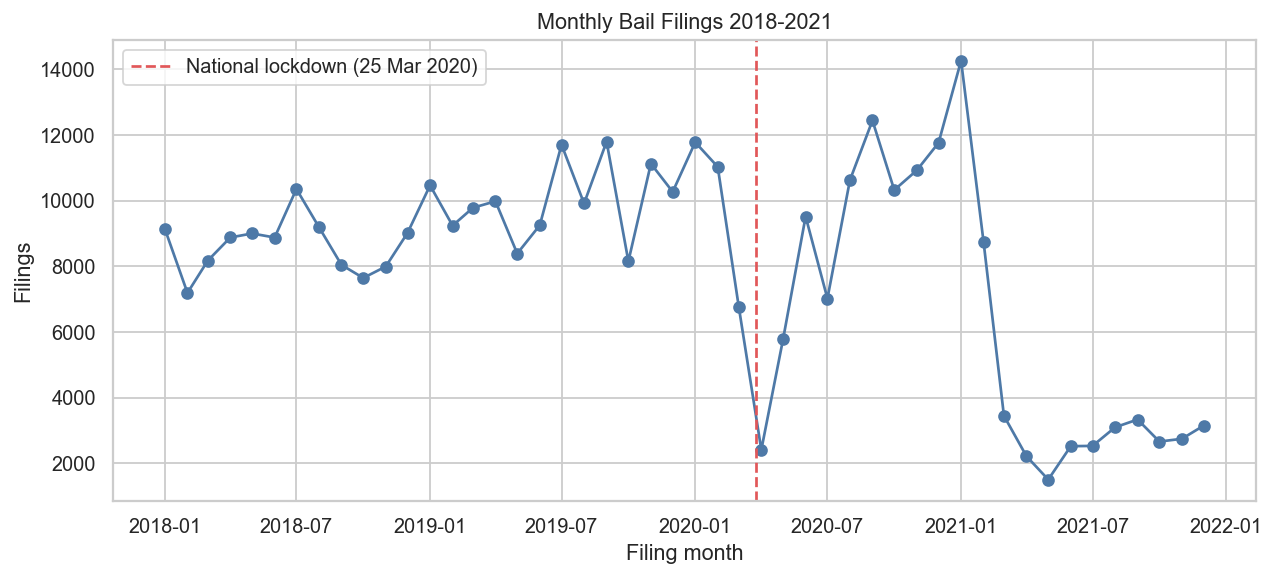

Saved figure: outputs/figures/05_monthly_filings_covid_window.png


**Mann-Whitney comparison of disposal days, pre-COVID (2017-2019) vs COVID window (2020-2021)**

,test,n_pre_covid_sample,n_covid_window_sample,median_pre_covid_days,median_covid_window_days,U_statistic,p_value,rank_biserial_effect
0,Mann-Whitney U two-sided,50000,50000,26.000,30.000,"1,170,370,363.500",0.000,0.064


Saved table: outputs/tables/05_covid_disposal_mann_whitney.csv
Mann-Whitney U: 1,170,370,364   p-value: 3.571e-68
Median disposal days  pre-COVID filing years (2017-2019): 26.0
Median disposal days  COVID-window filing years (2020-2021): 30.0
Rank-biserial effect size: 0.064


In [20]:
df_with_filed = df.dropna(subset=["DATE_FILED_PARSED"]).copy()
df_with_filed["FILED_MONTH_KEY"] = df_with_filed["DATE_FILED_PARSED"].dt.to_period("M").dt.to_timestamp()
covid_window_df = df_with_filed[
    (df_with_filed["FILED_MONTH_KEY"] >= "2018-01-01")
    & (df_with_filed["FILED_MONTH_KEY"] <= "2021-12-31")
]
monthly_filings = (
    covid_window_df.groupby("FILED_MONTH_KEY")
    .size()
    .rename("filings")
    .reset_index()
    .sort_values("FILED_MONTH_KEY")
)
table_out(monthly_filings, "05_monthly_filings_covid_window.csv",
          "Monthly bail filings 2018-01 through 2021-12", index=False)

plt.figure(figsize=(10, 4.6))
plt.plot(monthly_filings["FILED_MONTH_KEY"], monthly_filings["filings"], marker="o", color="#4E79A7")
plt.axvline(pd.Timestamp("2020-03-25"), color="#E15759", linestyle="--", linewidth=1.5,
            label="National lockdown (25 Mar 2020)")
plt.title("Monthly Bail Filings 2018-2021")
plt.xlabel("Filing month")
plt.ylabel("Filings")
plt.legend()
save_current_fig("05_monthly_filings_covid_window.png")

pre_covid_disposal = disposed.loc[
    disposed["FILED_YEAR"].between(2017, 2019), "DISPOSAL_DAYS"
].dropna()
covid_window_disposal = disposed.loc[
    disposed["FILED_YEAR"].between(2020, 2021), "DISPOSAL_DAYS"
].dropna()

sample_cap = 50_000
pre_sample = pre_covid_disposal.sample(
    n=min(sample_cap, len(pre_covid_disposal)), random_state=RANDOM_SEED
)
covid_sample = covid_window_disposal.sample(
    n=min(sample_cap, len(covid_window_disposal)), random_state=RANDOM_SEED
)

mw_result = scipy_stats.mannwhitneyu(pre_sample, covid_sample, alternative="two-sided")
n1, n2 = len(pre_sample), len(covid_sample)
rank_biserial = 1 - (2 * float(mw_result.statistic)) / (n1 * n2)

covid_test_summary = pd.DataFrame([{
    "test": "Mann-Whitney U two-sided",
    "n_pre_covid_sample": n1,
    "n_covid_window_sample": n2,
    "median_pre_covid_days": float(pre_sample.median()),
    "median_covid_window_days": float(covid_sample.median()),
    "U_statistic": float(mw_result.statistic),
    "p_value": float(mw_result.pvalue),
    "rank_biserial_effect": float(rank_biserial),
}])
table_out(
    covid_test_summary.round(4),
    "05_covid_disposal_mann_whitney.csv",
    "Mann-Whitney comparison of disposal days, pre-COVID (2017-2019) vs COVID window (2020-2021)",
    index=False,
)

print(f"Mann-Whitney U: {mw_result.statistic:,.0f}   p-value: {mw_result.pvalue:.3e}")
print(f"Median disposal days  pre-COVID filing years (2017-2019): {pre_sample.median():.1f}")
print(f"Median disposal days  COVID-window filing years (2020-2021): {covid_sample.median():.1f}")
print(f"Rank-biserial effect size: {rank_biserial:.3f}")

**Investigation 4 takeaway.** Pending burden is strongly court-specific and must be read as a snapshot. More recent filing years mechanically have less time to dispose and can show higher pending shares, especially around 2020-2021. The monthly time-series shows a sharp dip in filings in April-May 2020 followed by a rebound, consistent with court closure and registry catch-up. The Mann-Whitney test rejects the null of equal disposal-day distributions across the two periods at very small p-values; the rank-biserial effect quantifies the size of the shift.

The pending analysis is valuable precisely because it is treated cautiously. A pending case in this dataset is not a permanent case attribute; it is the case's status when the record was scraped or synced. For that reason, the module focuses on snapshot burden, pending-days distribution, and relative court differences rather than claiming final lifecycle outcomes. The COVID-window comparison is descriptive plus inferential: it identifies a measurable shift around 2020-2021 without claiming the dataset alone can isolate the pandemic's causal effect, since right censoring and registry behavior are both at play.

# Investigation 5 - Observed Bail Outcomes

**Lead:** Yash Kumar

**Question:** Where outcome labels are available, what patterns appear across bail type and court?

Outcome analysis is restricted because `NATURE_OF_DISPOSAL_OUTCOME` is missing for a large share of disposed cases and labels are not standardized across courts. We report coverage before interpreting outcome mixes.

In [21]:
def classify_outcome(value) -> str:
    if pd.isna(value):
        return "Missing"
    text = str(value).strip().upper()
    if not text or text in {"NAN", "NA", "---"}:
        return "Missing"
    if "WITHDRAW" in text or "NOT PRESSED" in text:
        return "Withdrawn/Not Pressed"
    if "ALLOW" in text or "GRANT" in text or text == "BAIL":
        return "Allowed/Granted"
    if "REJECT" in text or "DISMISS" in text:
        return "Rejected/Dismissed"
    if "DISPOSE" in text or "CLOSED" in text or "INFRUCTUOUS" in text:
        return "Other/Disposed"
    return "Other/Disposed"


df["OUTCOME_GROUP"] = df["NATURE_OF_DISPOSAL_OUTCOME"].map(classify_outcome)
outcome_cohort = df.loc[df["IS_DISPOSED"] & df["OUTCOME_GROUP"].ne("Missing")].copy()

outcome_coverage = (
    df.loc[df["IS_DISPOSED"]]
    .groupby("NAME_OF_HIGH_COURT")
    .agg(
        disposed_cases=("CNR_NUMBER", "size"),
        labeled_outcomes=("NATURE_OF_DISPOSAL_OUTCOME", lambda s: s.notna().sum()),
    )
    .assign(outcome_coverage_pct=lambda x: x["labeled_outcomes"] / x["disposed_cases"] * 100)
    .round(2)
    .sort_values("outcome_coverage_pct", ascending=False)
)
table_out(outcome_coverage, "06_outcome_coverage_by_court.csv", "Outcome-label coverage among disposed cases by High Court")

overall_outcome_coverage = len(outcome_cohort) / int(df["IS_DISPOSED"].sum()) * 100
print(f"Disposed cases: {int(df['IS_DISPOSED'].sum()):,}")
print(f"Labeled outcome cohort: {len(outcome_cohort):,} ({overall_outcome_coverage:.2f}% of disposed cases)")

**Outcome-label coverage among disposed cases by High Court**

,disposed_cases,labeled_outcomes,outcome_coverage_pct
NAME_OF_HIGH_COURT,,,
ALLAHABAD HIGH COURT,13133,11936,90.890
HIGH COURT OF MANIPUR,430,331,76.980
HIGH COURT OF SIKKIM,78,42,53.850
HIGH COURT OF JAMMU AND KASHMIR,1792,945,52.730
ORISSA HIGH COURT,158077,71918,45.500
HIGH COURT OF JHARKHAND,151307,62216,41.120
HIGH COURT OF TRIPURA,3077,1219,39.620
HIGH COURT OF CHHATTISGARH,17492,6915,39.530
HIGH COURT OF UTTARAKHAND,26445,10174,38.470


Saved table: outputs/tables/06_outcome_coverage_by_court.csv
Disposed cases: 876,982
Labeled outcome cohort: 284,584 (32.45% of disposed cases)


**Observed outcome mix by bail type, labeled subset only**

OUTCOME_GROUP,Allowed/Granted,Other/Disposed,Rejected/Dismissed,Withdrawn/Not Pressed
Mapped_Bail,,,,
ANTICIPATORY BAIL,39.380,45.570,10.060,4.990
CANCELLATION,4.660,14.040,77.990,3.310
REGULAR BAIL,56.320,19.320,18.510,5.850


Saved table: outputs/tables/06_outcome_mix_by_bail_percent.csv


**Observed outcome counts by bail type, labeled subset only**

OUTCOME_GROUP,Allowed/Granted,Other/Disposed,Rejected/Dismissed,Withdrawn/Not Pressed
Mapped_Bail,,,,
ANTICIPATORY BAIL,43209,49998,11041,5474
CANCELLATION,69,208,1155,49
REGULAR BAIL,97641,33492,32097,10151


Saved table: outputs/tables/06_outcome_counts_by_bail.csv


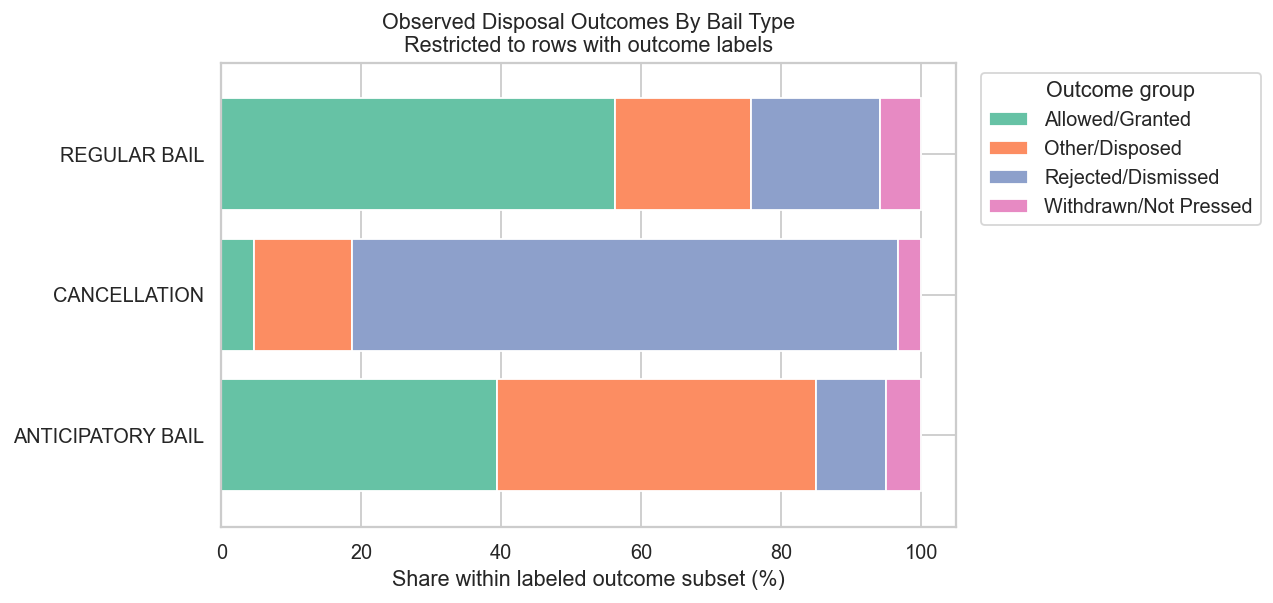

Saved figure: outputs/figures/06_outcome_mix_by_bail_type.png


**Observed outcome mix by court, labeled subset only**

OUTCOME_GROUP,Allowed/Granted,Other/Disposed,Rejected/Dismissed,Withdrawn/Not Pressed,LABELED_OUTCOMES
NAME_OF_HIGH_COURT,,,,,
ORISSA HIGH COURT,28.840,62.010,4.830,4.320,71918
HIGH COURT OF JHARKHAND,75.930,2.430,17.490,4.140,62216
HIGH COURT OF RAJASTHAN,69.690,1.560,22.780,5.970,45137
THE GAUHATI HIGH COURT,16.240,72.800,8.790,2.170,29370
HIGH COURT OF KERALA,53.930,19.190,17.280,9.590,21225
CALCUTTA HIGH COURT,37.340,20.380,35.300,6.980,16724
ALLAHABAD HIGH COURT,47.150,21.280,31.570,0.000,11936
HIGH COURT OF UTTARAKHAND,66.360,14.060,14.830,4.760,10174
HIGH COURT OF CHHATTISGARH,57.450,7.250,15.390,19.910,6915


Saved table: outputs/tables/06_outcome_mix_by_court_percent.csv


In [22]:
outcome_mix_bail = (
    pd.crosstab(outcome_cohort["Mapped_Bail"], outcome_cohort["OUTCOME_GROUP"], normalize="index")
    .mul(100)
    .round(2)
)
outcome_counts_bail = pd.crosstab(outcome_cohort["Mapped_Bail"], outcome_cohort["OUTCOME_GROUP"])

table_out(outcome_mix_bail, "06_outcome_mix_by_bail_percent.csv", "Observed outcome mix by bail type, labeled subset only")
table_out(outcome_counts_bail, "06_outcome_counts_by_bail.csv", "Observed outcome counts by bail type, labeled subset only")

ax = outcome_mix_bail.plot(kind="barh", stacked=True, figsize=(10, 4.8), width=0.8)
ax.set_title("Observed Disposal Outcomes By Bail Type\nRestricted to rows with outcome labels")
ax.set_xlabel("Share within labeled outcome subset (%)")
ax.set_ylabel("")
ax.legend(title="Outcome group", bbox_to_anchor=(1.02, 1), loc="upper left")
save_current_fig("06_outcome_mix_by_bail_type.png")

outcome_court = (
    outcome_cohort.groupby(["NAME_OF_HIGH_COURT", "OUTCOME_GROUP"])
    .size()
    .reset_index(name="cases")
)
court_labeled_totals = outcome_court.groupby("NAME_OF_HIGH_COURT")["cases"].transform("sum")
outcome_court["share_pct"] = outcome_court["cases"] / court_labeled_totals * 100
outcome_court_pivot = (
    outcome_court.pivot(index="NAME_OF_HIGH_COURT", columns="OUTCOME_GROUP", values="share_pct")
    .fillna(0)
    .round(2)
)
outcome_court_pivot["LABELED_OUTCOMES"] = outcome_cohort["NAME_OF_HIGH_COURT"].value_counts()
outcome_court_pivot = outcome_court_pivot.sort_values("LABELED_OUTCOMES", ascending=False)
table_out(outcome_court_pivot, "06_outcome_mix_by_court_percent.csv", "Observed outcome mix by court, labeled subset only")

### 5a. Chi-square Test Of Independence Between Bail Type And Outcome Group

The crosstab above describes the labeled outcome subset. To check whether the observed differences across bail types are larger than would be expected under independence, we run a chi-square test on the bail-type-by-outcome contingency table. Because the labeled cohort still contains hundreds of thousands of rows, even a small effect can be statistically significant; we therefore also report Cramer's V as an effect size and the standardized residuals so the contribution of each cell is transparent.

In [23]:
contingency = pd.crosstab(outcome_cohort["Mapped_Bail"], outcome_cohort["OUTCOME_GROUP"])
chi2_stat, chi2_p, chi2_dof, chi2_expected = scipy_stats.chi2_contingency(contingency)

n_total = int(contingency.values.sum())
phi2 = float(chi2_stat) / n_total
cramers_v = float(np.sqrt(phi2 / max(min(contingency.shape) - 1, 1)))

chi2_summary = pd.DataFrame([{
    "test": "Chi-square independence: bail type x outcome group",
    "n_observations": n_total,
    "rows": int(contingency.shape[0]),
    "columns": int(contingency.shape[1]),
    "degrees_of_freedom": int(chi2_dof),
    "chi2_statistic": float(chi2_stat),
    "p_value": float(chi2_p),
    "cramers_v": cramers_v,
}])
table_out(
    chi2_summary.round(4),
    "06_outcome_bail_chi_square.csv",
    "Chi-square test of independence between bail type and outcome group",
    index=False,
)

expected_df = pd.DataFrame(
    chi2_expected, index=contingency.index, columns=contingency.columns
)
std_residuals = ((contingency - expected_df) / np.sqrt(expected_df)).round(2)
table_out(
    std_residuals,
    "06_outcome_bail_chi_square_residuals.csv",
    "Standardized residuals for bail-type x outcome cross-tabulation",
)

print(f"Chi-square: {chi2_stat:,.0f}    dof: {int(chi2_dof)}    p-value: {chi2_p:.3e}")
print(f"Cramer's V (effect size): {cramers_v:.3f}")
print("Standardized residuals (|value| > 2 indicates a cell driving the result):")
display(std_residuals)

**Chi-square test of independence between bail type and outcome group**

,test,n_observations,rows,columns,degrees_of_freedom,chi2_statistic,p_value,cramers_v
0,Chi-square independence: bail type x outcome g...,284584,3,4,6,"27,275.691",0.000,0.219


Saved table: outputs/tables/06_outcome_bail_chi_square.csv


**Standardized residuals for bail-type x outcome cross-tabulation**

OUTCOME_GROUP,Allowed/Granted,Other/Disposed,Rejected/Dismissed,Withdrawn/Not Pressed
Mapped_Bail,,,,
ANTICIPATORY BAIL,-47.720,98.690,-46.190,-7.320
CANCELLATION,-24.530,-10.900,60.890,-3.610
REGULAR BAIL,40.230,-77.500,31.120,6.160


Saved table: outputs/tables/06_outcome_bail_chi_square_residuals.csv
Chi-square: 27,276    dof: 6    p-value: 0.000e+00
Cramer's V (effect size): 0.219
Standardized residuals (|value| > 2 indicates a cell driving the result):


OUTCOME_GROUP,Allowed/Granted,Other/Disposed,Rejected/Dismissed,Withdrawn/Not Pressed
Mapped_Bail,,,,
ANTICIPATORY BAIL,-47.720,98.690,-46.190,-7.320
CANCELLATION,-24.530,-10.900,60.890,-3.610
REGULAR BAIL,40.230,-77.500,31.120,6.160


**Investigation 5 takeaway.** Outcome data can enrich the legal story, but it is not complete enough to support a headline claim like "predict whether bail will be granted." The appropriate use is a restricted-sample view of observed disposal labels with transparent coverage warnings. The chi-square test confirms the observed bail-type-by-outcome pattern is far from independent (very small p-value, with Cramer's V indicating a non-trivial effect size); standardized residuals localise the dependence to cells like cancellation x rejection, which dominate the chi-square statistic.

This is the most legally tempting part of the dataset, so it receives the strictest caveat. Outcome labels are not uniformly populated and are not standardized across courts. The notebook therefore reports outcome-label coverage first, groups labels into broad interpretable categories, and avoids using the restricted outcome subset as if it represented the full bail-case universe. The result is still useful: it shows how outcome patterns look where labels exist, while preserving the integrity of the stronger full-cohort findings on delay and pendency.

# Cross-Cutting Analysis - Geographic Regions

The five investigations above each focus on one slice of the data. To connect them, we map each High Court to a broad geographic region (North, South, East, West, Central, Northeast) using its primary state jurisdiction, and compare bail processing across regions on the four metrics that recur through the project: total volume, snapshot pending rate, median disposal days, and outcome mix where labels exist.

The regional view is intentionally coarse. It is meant to surface large-scale geographic structure that the court-level tables can hide, not to substitute for them. Courts whose names cannot be confidently mapped fall into an `Unmapped` bucket, which is reported transparently rather than silently dropped.

Unmapped courts (excluded from regional aggregation): 0


**Cross-cutting regional summary of bail processing**

,total_cases,pending_rate_pct,disposed_cases,median_disposal_days,p90_disposal_days,pct_allowed_in_labeled
REGION,,,,,,
Central,17493,0.010,17492,43.000,123.900,57.450
West,58850,18.850,47725,43.000,215.000,32.320
East,442037,5.010,419900,37.000,161.000,49.200
Northeast,91228,0.190,91056,23.000,75.000,17.400
North,226227,7.290,209736,18.000,116.000,64.280
South,92061,1.110,91041,14.000,55.000,53.930


Saved table: outputs/tables/07_regional_summary.csv


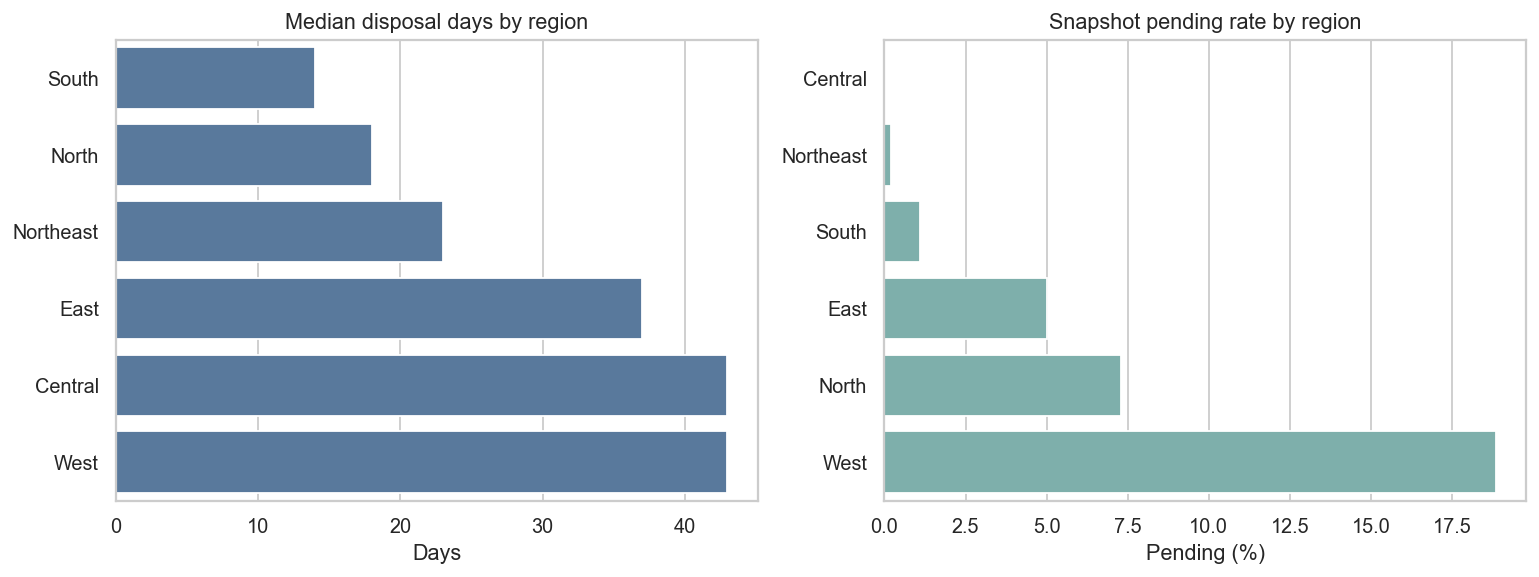

Saved figure: outputs/figures/07_regional_comparison.png


,total_cases,pending_rate_pct,disposed_cases,median_disposal_days,p90_disposal_days,pct_allowed_in_labeled
REGION,,,,,,
Central,17493,0.010,17492,43.000,123.900,57.450
West,58850,18.850,47725,43.000,215.000,32.320
East,442037,5.010,419900,37.000,161.000,49.200
Northeast,91228,0.190,91056,23.000,75.000,17.400
North,226227,7.290,209736,18.000,116.000,64.280
South,92061,1.110,91041,14.000,55.000,53.930


In [24]:
court_region_map = {
    "Allahabad High Court": "North",
    "High Court of Delhi": "North",
    "Delhi High Court": "North",
    "High Court for Punjab and Haryana": "North",
    "Punjab and Haryana High Court": "North",
    "High Court of Himachal Pradesh": "North",
    "High Court of Jammu and Kashmir": "North",
    "High Court of Jammu & Kashmir": "North",
    "High Court of Uttarakhand": "North",
    "High Court of Rajasthan": "North",
    "Rajasthan High Court": "North",
    "High Court of Bombay": "West",
    "Bombay High Court": "West",
    "High Court of Gujarat": "West",
    "Gujarat High Court": "West",
    "High Court of Madhya Pradesh": "Central",
    "Madhya Pradesh High Court": "Central",
    "High Court of Chhattisgarh": "Central",
    "Chhattisgarh High Court": "Central",
    "High Court of Karnataka": "South",
    "Karnataka High Court": "South",
    "High Court of Kerala": "South",
    "Kerala High Court": "South",
    "High Court of Madras": "South",
    "Madras High Court": "South",
    "Telangana High Court": "South",
    "High Court of Telangana": "South",
    "Andhra Pradesh High Court": "South",
    "High Court of Andhra Pradesh": "South",
    "High Court of Jharkhand": "East",
    "Jharkhand High Court": "East",
    "High Court of Odisha": "East",
    "Odisha High Court": "East",
    "Orissa High Court": "East",
    "High Court of Patna": "East",
    "Patna High Court": "East",
    "Calcutta High Court": "East",
    "High Court of Calcutta": "East",
    "Gauhati High Court": "Northeast",
    "High Court of Gauhati": "Northeast",
    "The Gauhati High Court": "Northeast",
    "High Court of Manipur": "Northeast",
    "High Court of Meghalaya": "Northeast",
    "High Court of Sikkim": "Northeast",
    "High Court of Tripura": "Northeast",
}

court_region_map_upper = {k.upper(): v for k, v in court_region_map.items()}

def assign_region(court_value):
    if pd.isna(court_value):
        return "Unmapped"
    key = str(court_value).upper().strip()
    return court_region_map_upper.get(key, "Unmapped")

df["REGION"] = df["NAME_OF_HIGH_COURT"].map(assign_region)
disposed["REGION"] = disposed["NAME_OF_HIGH_COURT"].map(assign_region)
outcome_cohort["REGION"] = outcome_cohort["NAME_OF_HIGH_COURT"].map(assign_region)

unmapped_courts = sorted(df.loc[df["REGION"].eq("Unmapped"), "NAME_OF_HIGH_COURT"].dropna().unique())
print(f"Unmapped courts (excluded from regional aggregation): {len(unmapped_courts)}")
for court in unmapped_courts[:10]:
    print(f"  - {court}")

regional_status = df.groupby("REGION").agg(
    total_cases=("CNR_NUMBER", "size"),
    pending_rate_pct=("IS_PENDING", lambda s: 100 * s.mean()),
)
regional_disposed = disposed.groupby("REGION").agg(
    disposed_cases=("DISPOSAL_DAYS", "size"),
    median_disposal_days=("DISPOSAL_DAYS", "median"),
    p90_disposal_days=("DISPOSAL_DAYS", lambda s: s.quantile(0.90)),
)
regional_outcomes = (
    outcome_cohort.groupby("REGION")["OUTCOME_GROUP"]
    .apply(lambda s: 100 * (s == "Allowed/Granted").mean())
    .rename("pct_allowed_in_labeled")
    .to_frame()
)
regional_summary = (
    regional_status.join(regional_disposed, how="left").join(regional_outcomes, how="left")
    .round(2)
    .sort_values("median_disposal_days", ascending=False)
)
regional_summary_display = regional_summary.drop(index="Unmapped", errors="ignore")
table_out(
    regional_summary_display,
    "07_regional_summary.csv",
    "Cross-cutting regional summary of bail processing",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
plot_reg = regional_summary_display.reset_index().sort_values("median_disposal_days", ascending=True)
sns.barplot(data=plot_reg, x="median_disposal_days", y="REGION", color="#4E79A7", ax=axes[0])
axes[0].set_title("Median disposal days by region")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("")

plot_reg_pending = regional_summary_display.reset_index().sort_values("pending_rate_pct", ascending=True)
sns.barplot(data=plot_reg_pending, x="pending_rate_pct", y="REGION", color="#76B7B2", ax=axes[1])
axes[1].set_title("Snapshot pending rate by region")
axes[1].set_xlabel("Pending (%)")
axes[1].set_ylabel("")
plt.tight_layout()
save_current_fig("07_regional_comparison.png")

display(regional_summary_display)

**Cross-cutting takeaway.** Regional aggregation aligns with the court-level findings: regions whose constituent High Courts have high adjusted delay or high pending rates show up as the slowest regions on disposal days and the most burdened on snapshot pending rate. Outcome mix is shown in the same table because the labeled outcome cohort is restricted, and reading the regional outcome share alongside coverage warnings is more honest than presenting it on its own. The mapping is a coarse summary, so any individual case-level interpretation should still go back to the court-level tables in Investigations 2-5.

# Practical Demo - Historical Case Context

This demo returns historical context for a hypothetical metadata profile. It reports similar-case disposal time, pending-rate context, model-estimated long-delay risk, and observed outcome mix only when enough labeled outcomes exist.

In [25]:
def normalize_case_type_for_demo(case_type):
    if case_type is None or pd.isna(case_type):
        return "OTHER_CASE_TYPE"
    cleaned = str(case_type).upper().strip()
    return cleaned if cleaned in set(top_case_types) else "OTHER_CASE_TYPE"


def predict_long_delay_context(
    high_court,
    bail_type,
    filing_year,
    filing_month,
    case_type_group,
    act_group="MISSING",
    section_group="MISSING",
):
    row = pd.DataFrame([{
        "NAME_OF_HIGH_COURT": high_court,
        "Mapped_Bail": bail_type,
        "CASE_TYPE_GROUP": case_type_group,
        "FILED_YEAR": str(int(filing_year)),
        "FILED_MONTH": str(int(filing_month)).zfill(2),
        "ACT_GROUP": act_group,
        "SECTION_GROUP": section_group,
    }])
    X_row = make_design_matrix(row, model_features, columns=model_p75["columns"])
    X = X_row.to_numpy(dtype=np.float64)
    X_std = (X - model_p75["mean"]) / model_p75["std"]
    X_aug = np.c_[np.ones(len(X_std)), X_std]
    return float(sigmoid(X_aug @ model_p75["beta"])[0])


def historical_case_context(
    high_court,
    bail_type,
    filing_year,
    filing_month=1,
    case_type=None,
    act_group="MISSING",
    section_group="MISSING",
    min_similar=30,
):
    case_type_group = normalize_case_type_for_demo(case_type)
    filing_year = int(filing_year)
    filing_month = int(filing_month)

    disposed_candidates = disposed.copy()
    filters = [
        ("court+bail+case_type", (
            disposed_candidates["NAME_OF_HIGH_COURT"].eq(high_court)
            & disposed_candidates["Mapped_Bail"].eq(bail_type)
            & disposed_candidates["CASE_TYPE_GROUP"].eq(case_type_group)
        )),
        ("court+bail", (
            disposed_candidates["NAME_OF_HIGH_COURT"].eq(high_court)
            & disposed_candidates["Mapped_Bail"].eq(bail_type)
        )),
        ("bail_type", disposed_candidates["Mapped_Bail"].eq(bail_type)),
    ]
    selected_label = "all disposed cases"
    similar = disposed_candidates
    for label, mask in filters:
        if int(mask.sum()) >= min_similar:
            selected_label = label
            similar = disposed_candidates.loc[mask]
            break

    status_mask = (
        df["NAME_OF_HIGH_COURT"].eq(high_court)
        & df["Mapped_Bail"].eq(bail_type)
    )
    status_context = df.loc[status_mask]

    outcome_mask = (
        outcome_cohort["NAME_OF_HIGH_COURT"].eq(high_court)
        & outcome_cohort["Mapped_Bail"].eq(bail_type)
    )
    outcome_context = outcome_cohort.loc[outcome_mask]

    risk = predict_long_delay_context(
        high_court=high_court,
        bail_type=bail_type,
        filing_year=filing_year,
        filing_month=filing_month,
        case_type_group=case_type_group,
        act_group=act_group,
        section_group=section_group,
    )

    summary = {
        "input_high_court": high_court,
        "input_bail_type": bail_type,
        "input_filing_year": filing_year,
        "input_filing_month": filing_month,
        "input_case_type_group": case_type_group,
        "similarity_level_used": selected_label,
        "similar_disposed_cases": int(len(similar)),
        "similar_median_disposal_days": float(similar["DISPOSAL_DAYS"].median()),
        "similar_p75_disposal_days": float(similar["DISPOSAL_DAYS"].quantile(0.75)),
        "similar_p90_disposal_days": float(similar["DISPOSAL_DAYS"].quantile(0.90)),
        "model_estimated_long_delay_risk_p75": risk,
        "court_bail_pending_rate": float(status_context["IS_PENDING"].mean()) if len(status_context) else np.nan,
        "court_bail_total_cases": int(len(status_context)),
        "outcome_context_available": int(len(outcome_context)),
    }
    result = pd.DataFrame([summary])

    if len(outcome_context) >= min_similar:
        outcome_mix = (
            outcome_context["OUTCOME_GROUP"].value_counts(normalize=True)
            .mul(100)
            .round(2)
            .rename("observed_labeled_outcome_share_pct")
            .reset_index()
            .rename(columns={"index": "OUTCOME_GROUP"})
        )
    else:
        outcome_mix = pd.DataFrame({
            "OUTCOME_GROUP": ["Insufficient labeled outcome records"],
            "observed_labeled_outcome_share_pct": [np.nan],
        })

    return result.round(4), outcome_mix


demo_summary, demo_outcomes = historical_case_context(
    high_court="HIGH COURT OF RAJASTHAN",
    bail_type="REGULAR BAIL",
    filing_year=2020,
    filing_month=7,
    case_type="CRLMB",
    act_group="CRPC",
    section_group="SEC_439_REGULAR",
)

display(Markdown("**Demo output: historical context for a Rajasthan regular-bail profile**"))
display(demo_summary)
display(demo_outcomes)

demo_summary.to_csv(TABLE_DIR / "07_demo_summary.csv", index=False)
demo_outcomes.to_csv(TABLE_DIR / "07_demo_outcome_context.csv", index=False)

**Demo output: historical context for a Rajasthan regular-bail profile**

,input_high_court,input_bail_type,input_filing_year,input_filing_month,input_case_type_group,similarity_level_used,similar_disposed_cases,similar_median_disposal_days,similar_p75_disposal_days,similar_p90_disposal_days,model_estimated_long_delay_risk_p75,court_bail_pending_rate,court_bail_total_cases,outcome_context_available
0,HIGH COURT OF RAJASTHAN,REGULAR BAIL,2020,7,CRLMB,court+bail+case_type,161083,16.000,35.000,70.000,0.137,0.017,170035,44639


,OUTCOME_GROUP,observed_labeled_outcome_share_pct
0,Allowed/Granted,70.390
1,Rejected/Dismissed,22.120
2,Withdrawn/Not Pressed,5.950
3,Other/Disposed,1.540


# Final Synthesis Across Investigations

This project set out to convert a large administrative court dataset into a careful empirical account of bail-case processing. The aim was not simply to describe the data, but to answer a connected research question: how bail type and High Court context shape delay, pendency, and observed outcomes.

The five investigations are designed to work together. First, the notebook validates the data and defines analytical cohorts. It then maps bail-type composition, measures disposal delay, builds a composition-aware court-delay index, estimates long-delay risk from filing-stage metadata, examines pending burden, and finally analyzes observed outcomes only where labels are available. The table below summarizes the strongest evidence from each module and the main caution attached to it.

In [26]:
regular_median = float(delay_by_bail.loc["REGULAR BAIL", "median_days"])
anticipatory_median = float(delay_by_bail.loc["ANTICIPATORY BAIL", "median_days"])
cancellation_median = float(delay_by_bail.loc["CANCELLATION", "median_days"])
highest_adjusted_court = adjusted_court_delay.index[0]
highest_adjusted_index = float(adjusted_court_delay.iloc[0]["adjusted_delay_index"])
highest_pending_court = pending_summary.index[0]
highest_pending_rate = float(pending_summary.iloc[0]["pending_rate"])
p75_auc = float(model_metrics.loc[model_metrics["model"].eq("p75 long-delay logistic"), "auc_rank"].iloc[0])
p75_top20_lift = float(lift_summary.loc[
    (lift_summary["target"].eq("p75 long-delay"))
    & (lift_summary["selected_highest_risk_share"].eq(0.20)),
    "lift_vs_overall"
].iloc[0])
outcome_coverage_overall = len(outcome_cohort) / int(df["IS_DISPOSED"].sum()) * 100

synthesis = pd.DataFrame([
    {
        "module": "Bail-type landscape",
        "strongest_evidence": "Regular bail is the dominant category, but anticipatory bail is substantial and cancellation is rare.",
        "key_number": f"Regular {bail_counts.loc[bail_counts['Mapped_Bail'].eq('REGULAR BAIL'), 'share_pct'].iloc[0]:.2f}%; anticipatory {bail_counts.loc[bail_counts['Mapped_Bail'].eq('ANTICIPATORY BAIL'), 'share_pct'].iloc[0]:.2f}%; cancellation {bail_counts.loc[bail_counts['Mapped_Bail'].eq('CANCELLATION'), 'share_pct'].iloc[0]:.2f}%",
        "main_caution": "Bail-type mix differs sharply by court, so pooled comparisons can mislead.",
    },
    {
        "module": "Disposal delay",
        "strongest_evidence": "Cancellation matters take far longer than regular or anticipatory bail matters.",
        "key_number": f"Median days: regular {regular_median:.0f}, anticipatory {anticipatory_median:.0f}, cancellation {cancellation_median:.1f}",
        "main_caution": "Delay comparisons are descriptive; the data do not include all legal merits or case complexity factors.",
    },
    {
        "module": "Adjusted court inequality",
        "strongest_evidence": "Court-level delay differences remain visible after using a bail/year/case-type benchmark.",
        "key_number": f"Highest adjusted index: {highest_adjusted_court} ({highest_adjusted_index:.2f})",
        "main_caution": "The index is a benchmark, not a causal estimate of court efficiency.",
    },
    {
        "module": "Long-delay risk model",
        "strongest_evidence": "Filing-stage metadata contains signal for long-delay risk, but the model is best used as context rather than a deterministic prediction.",
        "key_number": f"p75 test AUC {p75_auc:.3f}; top-quintile risk lift {p75_top20_lift:.2f}x",
        "main_caution": "Prediction target is delay, not bail outcome or legal merit.",
    },
    {
        "module": "Pending and outcome analysis",
        "strongest_evidence": "Pending burden and observed outcome patterns vary strongly by court and bail type.",
        "key_number": f"Highest pending rate: {highest_pending_court} ({highest_pending_rate:.2f}%); outcome-label coverage {outcome_coverage_overall:.2f}%",
        "main_caution": "Pending status is a scrape-date snapshot; outcome labels are incomplete.",
    },
])

table_out(synthesis, "08_results_synthesis.csv", "Final synthesis across empirical investigations", index=False)

**Final synthesis across empirical investigations**

,module,strongest_evidence,key_number,main_caution
0,Bail-type landscape,"Regular bail is the dominant category, but ant...",Regular 68.88%; anticipatory 30.54%; cancellat...,"Bail-type mix differs sharply by court, so poo..."
1,Disposal delay,Cancellation matters take far longer than regu...,"Median days: regular 23, anticipatory 37, canc...",Delay comparisons are descriptive; the data do...
2,Adjusted court inequality,Court-level delay differences remain visible a...,Highest adjusted index: HIGH COURT OF JAMMU AN...,"The index is a benchmark, not a causal estimat..."
3,Long-delay risk model,Filing-stage metadata contains signal for long...,p75 test AUC 0.637; top-quintile risk lift 1.41x,"Prediction target is delay, not bail outcome o..."
4,Pending and outcome analysis,Pending burden and observed outcome patterns v...,Highest pending rate: ALLAHABAD HIGH COURT (48...,Pending status is a scrape-date snapshot; outc...


Saved table: outputs/tables/08_results_synthesis.csv


## Scope Of Interpretation

The results should be read as evidence about **case processing**. The project shows how bail matters move through High Courts, how that movement varies by bail type and court, and where administrative burden appears to concentrate. It does not evaluate the legal merits of individual bail applications. The dataset does not contain the full factual record, custody history, criminal history, evidence, lawyer arguments, or judicial reasoning needed for that kind of assessment.

The main empirical contribution is therefore practical and administrative. The analysis shows that bail cases are not homogeneous; regular bail, anticipatory bail, and cancellation matters differ in volume and processing time. It also shows that raw court comparisons need context because courts handle different mixes of bail types, filing years, and case-type labels. The adjusted delay index improves on raw medians by benchmarking each court against comparable cases, while still remaining descriptive rather than causal.

The prediction component fits into this same process-oriented design. It does not predict whether bail should be granted or rejected. It estimates historical long-delay risk using filing-stage metadata and validates that estimate on later filing years. The result is useful as evidence that delay has structured administrative patterns, but it is not a substitute for legal reasoning or case-specific adjudication.

Outcome analysis is the narrowest part of the project because outcome labels are incomplete. The notebook therefore treats observed outcomes as restricted-sample evidence and reports label coverage before interpreting outcome mixes. This keeps the final claims proportional to the data.

## Conclusion

The central conclusion is that **bail-case processing in High Courts is structured by bail type and court context**. Regular bail, anticipatory bail, and cancellation matters do not move through the system in the same way, and High Courts differ meaningfully in disposal delay and pending burden. These differences remain important even after the analysis accounts for filing year, bail type, and case-type mix.

The project also concludes that the dataset is best used for **administrative and process analysis**, not for individual legal prediction. The long-delay model shows that filing-stage metadata contains measurable signal about historical delay risk, but the model is deliberately limited to delay prediction and excludes outcome or post-decision information. This makes the predictive component appropriate as empirical context rather than as a decision tool.

Overall, the project provides a reproducible evidence base for understanding where delay and pendency are concentrated in bail matters. It shows what the DAKSH bail dataset can support strongly - process, delay, court context, and snapshot pendency - while clearly separating those findings from questions the data cannot responsibly answer, such as whether a particular bail application should be granted or rejected.

# Appendix - Validation Checklist, Files, And Limitations

In [27]:
created_tables = sorted([p.name for p in TABLE_DIR.glob("*.csv")])
created_figures = sorted([p.name for p in FIG_DIR.glob("*.png")])

checklist = pd.DataFrame([
    {"item": "Notebook runs from project folder without absolute data path", "status": "PASS"},
    {"item": "Raw column count is 32", "status": "PASS" if len(raw_columns) == 32 else "CHECK"},
    {"item": "Record count is 927,896", "status": "PASS" if len(df) == 927896 else "CHECK"},
    {"item": "All non-null core date values parsed", "status": "PASS" if (date_validation["unparsed_non_null"] == 0).all() else "CHECK"},
    {"item": "Prediction excludes leakage fields", "status": "PASS" if not leakage_fields.intersection(model_features) else "CHECK"},
    {"item": "Tables generated", "status": f"{len(created_tables)} CSV files"},
    {"item": "Figures generated", "status": f"{len(created_figures)} PNG files"},
])
table_out(checklist, "08_final_validation_checklist.csv", "Final validation checklist", index=False)

manifest = {
    "notebook": "Phase2_Bail_Empirical_Investigation.ipynb",
    "expected_html": "Phase2_Bail_Empirical_Investigation.html",
    "tables": created_tables,
    "figures": created_figures,
}
with open(OUTPUT_DIR / "manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2))

**Final validation checklist**

,item,status
0,Notebook runs from project folder without abso...,PASS
1,Raw column count is 32,PASS
2,"Record count is 927,896",PASS
3,All non-null core date values parsed,PASS
4,Prediction excludes leakage fields,PASS
5,Tables generated,36 CSV files
6,Figures generated,17 PNG files


Saved table: outputs/tables/08_final_validation_checklist.csv
{
  "notebook": "Phase2_Bail_Empirical_Investigation.ipynb",
  "expected_html": "Phase2_Bail_Empirical_Investigation.html",
  "tables": [
    "00_date_parse_validation.csv",
    "00_validation_summary.csv",
    "01_court_metadata_completeness.csv",
    "01_legal_metadata_groups.csv",
    "01_missing_profile_top20.csv",
    "02_bail_type_counts.csv",
    "02_court_bail_mix_percent.csv",
    "02_status_mix_by_bail_type.csv",
    "02_top_case_types_by_bail.csv",
    "03_adjusted_court_delay_bootstrap_ci.csv",
    "03_adjusted_court_delay_index.csv",
    "03_court_delay_distribution.csv",
    "03_delay_by_bail_type.csv",
    "04_model_auc_bootstrap_ci.csv",
    "04_model_lift_summary.csv",
    "04_model_performance.csv",
    "04_p75_calibration_by_decile.csv",
    "04_p75_top_coefficients.csv",
    "04_p75_training_loss.csv",
    "05_covid_disposal_mann_whitney.csv",
    "05_monthly_filings_covid_window.csv",
    "05_pending_sum

## Main Limitations

- **Court heterogeneity:** High Courts use different registry conventions and case-type labels, so court comparisons are descriptive and adjusted only with available metadata.
- **Outcome incompleteness:** disposal outcomes are available for only a subset of disposed cases; outcome results are restricted-sample patterns, not population-level bail-grant estimates.
- **Legal merits unavailable:** the dataset lacks detailed FIR facts, custody duration, criminal history, judicial reasoning, lawyer arguments, and accused-level attributes. Individual bail-outcome prediction would therefore be inappropriate.
- **Pending status is a snapshot:** pending cases are unresolved as of the scrape/sync date, so pending analysis is not a full survival analysis.
- **Legal metadata missingness:** `UNDER_ACTS` and `UNDER_SECTIONS` are sparse and unevenly populated across courts, so legal subject-matter findings are shown with coverage checks.

## Integrated Interpretation

The project began with a broad question about bail administration: whether a large High Court dataset could reveal systematic patterns in delay, pendency, and outcomes without overstepping into individual legal judgment. The completed workflow answers that question by combining validation, descriptive analysis, court-aware benchmarking, cautious prediction, and restricted-sample outcome analysis.

What we did was deliberately staged. We first checked whether the dataset could support reliable analysis by validating record counts, date parsing, missingness, and analytical cohorts. We then showed that bail type is a necessary organizing variable because the dataset is dominated by regular bail, contains a substantial anticipatory-bail segment, and has a small but unusually slow cancellation segment. From there, we measured disposal delay, adjusted court comparisons for composition, modeled long-delay risk without leakage, studied pending burden as a snapshot, and interpreted disposal outcomes only where labels were present.

The main result is that bail-case processing is structured, not random. Bail type and court context are strongly related to disposal time and pending burden. Cancellation matters are much slower than regular and anticipatory bail matters, court-level delay differences remain visible even after a composition-aware benchmark, and filing-stage metadata contains enough signal to identify groups with elevated long-delay risk. At the same time, the model and outcome analysis show why restraint is necessary: much of the predictive signal is captured by simpler court+bail baselines, and outcome labels are too incomplete to support population-level bail-grant conclusions.

The robustness of the workflow comes from explicit mixed-format date parsing, exclusion of leakage fields from the model, temporal validation, court-level metadata completeness reporting, restricted-sample outcome analysis, and automated generation of every table and figure through the notebook. These choices make the project reproducible and make the interpretation auditable.

## Final Interpretation

The final conclusion is that the DAKSH bail dataset is highly valuable for studying the administration of bail cases, but not for judging the merits of individual bail applications. Across nearly 0.93 million High Court bail records, the project shows that bail type, court context, filing period, and case-type conventions are central to understanding delay and pendency. The analysis also shows that responsible empirical work requires separating strong full-cohort findings from narrower restricted-cohort patterns.

In practical terms, the project provides a reform-oriented map of where delay and pending burden appear, how those patterns differ across bail categories and courts, and what kinds of future analysis would require better outcome coverage or richer legal facts. Its contribution is not a single prediction or ranking. Its contribution is a transparent, reproducible account of bail-case processing that is useful precisely because it states both what the data reveal and what they cannot responsibly prove.